<a href="https://colab.research.google.com/github/parthdasawant/UDL/blob/main/dimensionality_reduction_BITS_Final1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dimensionality Reduction & Latent Variable Methods

A working notebook for our class. We'll build intuition through code and visualization, covering:

- **PCA** — the workhorse linear method
- **Kernel PCA** — when data lives on a curved manifold
- **ICA** — separating mixed sources (the cocktail-party problem)
- **Factor Analysis** — when noise matters
- **CCA** — finding shared structure across two views

A note on the visualizations: I'll use `set_aspect('equal')` whenever the visual spread should match the actual numerical spread. Many tutorials autoscale plot axes, which makes a low-variance principal component look as spread out as a high-variance one. We won't do that.


## Setup

Run this first. We'll use scikit-learn, NumPy, matplotlib, and a few extras for audio and images.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from sklearn.decomposition import PCA, KernelPCA, FastICA, FactorAnalysis
from sklearn.cross_decomposition import CCA
from sklearn.datasets import (load_iris, load_digits, make_moons, make_circles,
                              fetch_openml, fetch_lfw_people)
from sklearn.preprocessing import StandardScaler
import scipy.signal as sg

np.random.seed(42)

# ---- Publication-grade visual style ---------------------------------------
# Curated palette inspired by scientific publishing conventions
PALETTE = {
    'navy':  '#1f3a5f',  # primary
    'rust':  '#c44536',  # accent / class 2
    'teal':  '#2a9d8f',  # class 3
    'gold':  '#e9b44c',  # highlight / class 4
    'plum':  '#6a4c93',  # class 5
    'slate': '#5a6c7d',  # secondary text
    'fog':   '#d8dee4',  # subtle borders
    'ink':   '#2a3744',  # primary text
}
# Categorical class colors — use the first N for any classification plot
CLASS_COLORS = [PALETTE['navy'], PALETTE['rust'], PALETTE['teal'],
                PALETTE['gold'], PALETTE['plum'], PALETTE['slate']]
# 10-class palette for digits / fashion-mnist / cifar-10
TEN_COLORS = ['#1f3a5f', '#c44536', '#2a9d8f', '#e9b44c', '#6a4c93',
              '#5a6c7d', '#d4895c', '#7da3a1', '#b3325a', '#586ba4']

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 200, 'figure.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'font.size': 10,
    'axes.titlesize': 11.5, 'axes.titleweight': 'bold', 'axes.titlepad': 10,
    'axes.titlelocation': 'left',
    'axes.labelsize': 10, 'axes.labelcolor': PALETTE['ink'],
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.frameon': False,
    'figure.titlesize': 13, 'figure.titleweight': 'bold',
    'axes.edgecolor': PALETTE['ink'], 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.color': PALETTE['ink'], 'ytick.color': PALETTE['ink'],
    'xtick.major.width': 0.8, 'ytick.major.width': 0.8,
    'xtick.major.size': 4,    'ytick.major.size': 4,
    'axes.grid': True, 'axes.axisbelow': True,
    'grid.color': '#eef0f3', 'grid.linewidth': 0.6,
    'lines.linewidth': 1.8, 'lines.markersize': 6,
    'patch.edgecolor': 'white',
})

def add_figtitle(fig, title, subtitle=None):
    """Two-line figure header: bold title + slate subtitle, both left-aligned."""
    fig.suptitle(title, fontweight='bold', fontsize=13, x=0.02, ha='left', y=0.98)
    if subtitle:
        fig.text(0.02, 0.93, subtitle, fontsize=10, color=PALETTE['slate'], ha='left')

def style_image_axes(ax, emphasize=False):
    """Clean spines for image plots: dark border if emphasized, fog otherwise."""
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    width = 1.8 if emphasize else 0.6
    color = PALETTE['ink'] if emphasize else PALETTE['fog']
    for s in ax.spines.values():
        s.set_color(color); s.set_linewidth(width); s.set_visible(True)

# Dataset availability flags
FASHION_OK = True
LFW_OK = True
CIFAR_OK = True

print('Setup complete. NumPy:', np.__version__)

Setup complete. NumPy: 2.0.2


---
# Part 1 — Principal Component Analysis (PCA)

## The intuition
PCA finds new orthogonal axes — the *principal components* — such that:
- **PC1** points in the direction of maximum variance in the data
- **PC2** is perpendicular to PC1 and captures the next most variance
- and so on

Think of PCA as **rotating the coordinate system** so the data's natural spread aligns with the plot axes. No information is lost — we're just looking at the same cloud through "PCA glasses."

## The math
Given centered data $X \in \mathbb{R}^{n \times d}$:

1. Covariance matrix: $\Sigma = \frac{1}{n-1} X^\top X$
2. Eigendecomposition: $\Sigma = V \Lambda V^\top$
3. Columns of $V$ are the principal components; eigenvalues $\lambda_i$ are the variances along each PC
4. Project: $Z = X V$

**Variance explained by PC$_i$**: $\lambda_i / \sum_j \lambda_j$


## Example 1.1 — A 2D correlated cloud, plotted honestly

The canonical "stretched ellipse" example. Equal aspect ratio so PC2 looks small *because it is small*.

In [2]:
# Generate correlated 2D data
n = 300
t = np.random.randn(n) * 3
X = np.column_stack([
    t + np.random.randn(n) * 0.5,
    0.6 * t + np.random.randn(n) * 0.5
])
labels = (t > 0).astype(int)

pca = PCA(n_components=2)
Z = pca.fit_transform(X)

print(f"Variance along PC1: {pca.explained_variance_[0]:.3f}")
print(f"Variance along PC2: {pca.explained_variance_[1]:.3f}")
print(f"Variance ratio:     {pca.explained_variance_ratio_}")
print(f"PC1 carries {pca.explained_variance_[0] / pca.explained_variance_[1]:.1f}x more variance than PC2")

Variance along PC1: 11.903
Variance along PC2: 0.250
Variance ratio:     [0.97939823 0.02060177]
PC1 carries 47.5x more variance than PC2


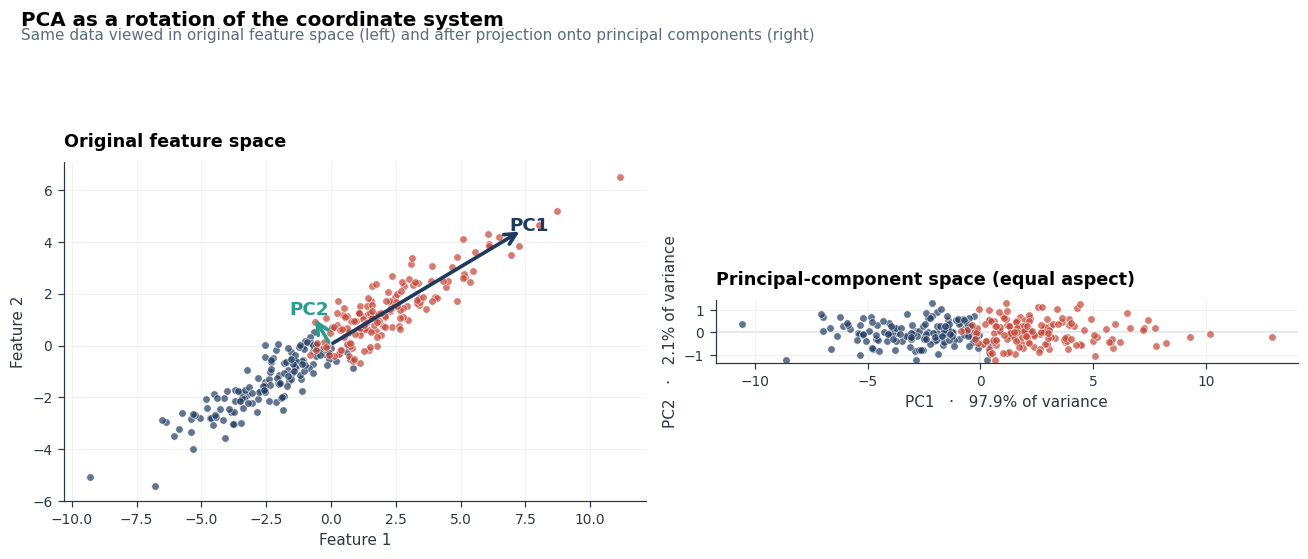

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
add_figtitle(fig, 'PCA as a rotation of the coordinate system',
             'Same data viewed in original feature space (left) and after projection onto principal components (right)')

# --- Left: original space with PC directions ---
ax = axes[0]
ax.scatter(X[labels==0, 0], X[labels==0, 1], c=PALETTE['navy'], s=24,
           alpha=0.7, edgecolor='white', linewidth=0.5)
ax.scatter(X[labels==1, 0], X[labels==1, 1], c=PALETTE['rust'], s=24,
           alpha=0.7, edgecolor='white', linewidth=0.5)

mean = pca.mean_
arrow_colors = [PALETTE['navy'], PALETTE['teal']]
for i, (length, vec) in enumerate(zip(pca.explained_variance_, pca.components_)):
    arrow_end = mean + 2.5 * np.sqrt(length) * vec
    ax.annotate('', xy=arrow_end, xytext=mean,
                arrowprops=dict(arrowstyle='->', color=arrow_colors[i],
                                lw=2.4, mutation_scale=18))
    label_offset = vec * 0.3
    ax.text(arrow_end[0] + label_offset[0], arrow_end[1] + label_offset[1],
            f'PC{i+1}', color=arrow_colors[i], fontsize=12, fontweight='bold',
            ha='center', va='center')

ax.set_title('Original feature space')
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.set_aspect('equal')

# --- Right: projection ---
ax = axes[1]
ax.scatter(Z[labels==0, 0], Z[labels==0, 1], c=PALETTE['navy'], s=24,
           alpha=0.7, edgecolor='white', linewidth=0.5)
ax.scatter(Z[labels==1, 0], Z[labels==1, 1], c=PALETTE['rust'], s=24,
           alpha=0.7, edgecolor='white', linewidth=0.5)
ax.axhline(0, color=PALETTE['fog'], lw=1, zorder=0)
ax.axvline(0, color=PALETTE['fog'], lw=1, zorder=0)
ax.set_title('Principal-component space (equal aspect)')
ax.set_xlabel(f'PC1   ·   {pca.explained_variance_ratio_[0]*100:.1f}% of variance')
ax.set_ylabel(f'PC2   ·   {pca.explained_variance_ratio_[1]*100:.1f}% of variance')
ax.set_aspect('equal')

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

**What we're looking at.** The right panel uses `set_aspect('equal')`, so one unit on the x-axis takes the same screen space as one unit on the y-axis. The cloud is genuinely a thin horizontal cigar — PC1 spans roughly ±8, PC2 spans roughly ±1. That ratio reflects the eigenvalue ratio printed above.

If we wanted to reduce 2D → 1D here, keeping only PC1 would throw away just ~6% of the variance. That's the point of PCA in one sentence.

## Example 1.2 — PCA on Iris (4D → 2D)

Real data. Four features, three flower species. We'll standardize first because features have different units.

In [4]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
target_names = iris.target_names

X_iris_std = StandardScaler().fit_transform(X_iris)

pca_iris = PCA(n_components=4).fit(X_iris_std)
Z_iris = pca_iris.transform(X_iris_std)

print("Variance explained by each PC:")
for i, r in enumerate(pca_iris.explained_variance_ratio_):
    print(f"  PC{i+1}: {r*100:5.1f}%")
print(f"\nPC1 + PC2 together: {pca_iris.explained_variance_ratio_[:2].sum()*100:.1f}%")

Variance explained by each PC:
  PC1:  73.0%
  PC2:  22.9%
  PC3:   3.7%
  PC4:   0.5%

PC1 + PC2 together: 95.8%


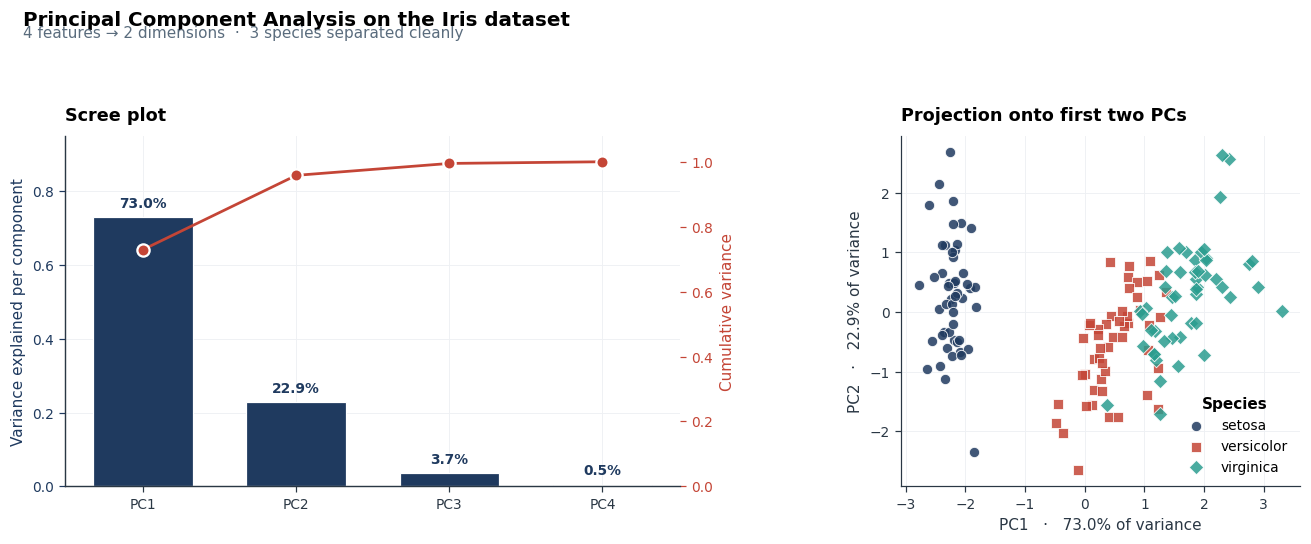

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
add_figtitle(fig, 'Principal Component Analysis on the Iris dataset',
             '4 features → 2 dimensions  ·  3 species separated cleanly')

# --- Scree plot with annotated bars and dual y-axis cumulative line ---
ax = axes[0]
xs = np.arange(1, 5)
bars = ax.bar(xs, pca_iris.explained_variance_ratio_,
              color=PALETTE['navy'], width=0.65,
              edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, pca_iris.explained_variance_ratio_):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.018,
            f'{val*100:.1f}%', ha='center', va='bottom',
            fontsize=9, color=PALETTE['navy'], fontweight='bold')

ax2 = ax.twinx()
ax2.plot(xs, np.cumsum(pca_iris.explained_variance_ratio_), 'o-',
         color=PALETTE['rust'], linewidth=1.8, markersize=8,
         markeredgecolor='white', markeredgewidth=1.5, label='Cumulative')
ax2.set_ylim(0, 1.08)
ax2.spines['top'].set_visible(False)
ax2.tick_params(axis='y', colors=PALETTE['rust'])
ax2.set_ylabel('Cumulative variance', color=PALETTE['rust'])
ax2.grid(False)

ax.set_xticks(xs); ax.set_xticklabels([f'PC{i}' for i in xs])
ax.set_ylabel('Variance explained per component', color=PALETTE['navy'])
ax.set_ylim(0, 0.95)
ax.set_title('Scree plot')
ax.tick_params(axis='y', colors=PALETTE['navy'])

# --- 2D projection by species ---
ax = axes[1]
markers = ['o', 's', 'D']
for cls in range(3):
    mask = y_iris == cls
    ax.scatter(Z_iris[mask, 0], Z_iris[mask, 1],
               c=CLASS_COLORS[cls], marker=markers[cls],
               s=45, alpha=0.85, edgecolor='white', linewidth=0.6,
               label=target_names[cls])
ax.set_xlabel(f'PC1   ·   {pca_iris.explained_variance_ratio_[0]*100:.1f}% of variance')
ax.set_ylabel(f'PC2   ·   {pca_iris.explained_variance_ratio_[1]*100:.1f}% of variance')
ax.set_title('Projection onto first two PCs')
ax.set_aspect('equal')
leg = ax.legend(title='Species', loc='lower right')
leg.get_title().set_fontweight('bold')

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

**Reading the scree plot.** PC1 captures ~73% of variance, PC2 another ~23%. Together that's 96% — dropping the bottom two components costs almost nothing. This is the standard way to decide how many components to keep: look for the elbow.

**Important caveat.** PCA is *not* designed to maximize class separability — it just maximizes variance. The fact that species separate well here is a happy coincidence. For supervised separation, use **Linear Discriminant Analysis (LDA)** instead.

---
# Part 1.5 — Dimensionality reduction in action: image reconstruction

So far we've projected and looked. The real promise of PCA is **compression**: throw away the small-variance components and keep the top $k$ — yet lose almost nothing visually meaningful.

We'll demonstrate this on three datasets of increasing visual complexity:

1. **Digits** (8×8 grayscale) — quick warmup, runs offline
2. **Fashion-MNIST** (28×28 grayscale clothing) — modern, instantly relatable
3. **LFW faces** (50×37 real face photographs) — the dramatic eigenfaces example
4. **CIFAR-10** (32×32 color natural images) — where PCA starts to struggle

The reconstruction formula is the heart of dimensionality reduction:
$$\hat{x} = \mu + \sum_{i=1}^{k} (x \cdot v_i)\, v_i$$

With $k = d$ we reconstruct perfectly. With $k \ll d$ we lose detail — but if PCA found good directions, the lost detail is mostly noise.


### Warmup: the digits dataset

Each handwritten digit is an 8×8 image, so a point in $\mathbb{R}^{64}$. We'll reconstruct at increasing $k$ to see where the digit "emerges" from blur to crisp.

Number of images: 1797
Image dimension: 8 × 8 = 64 pixels


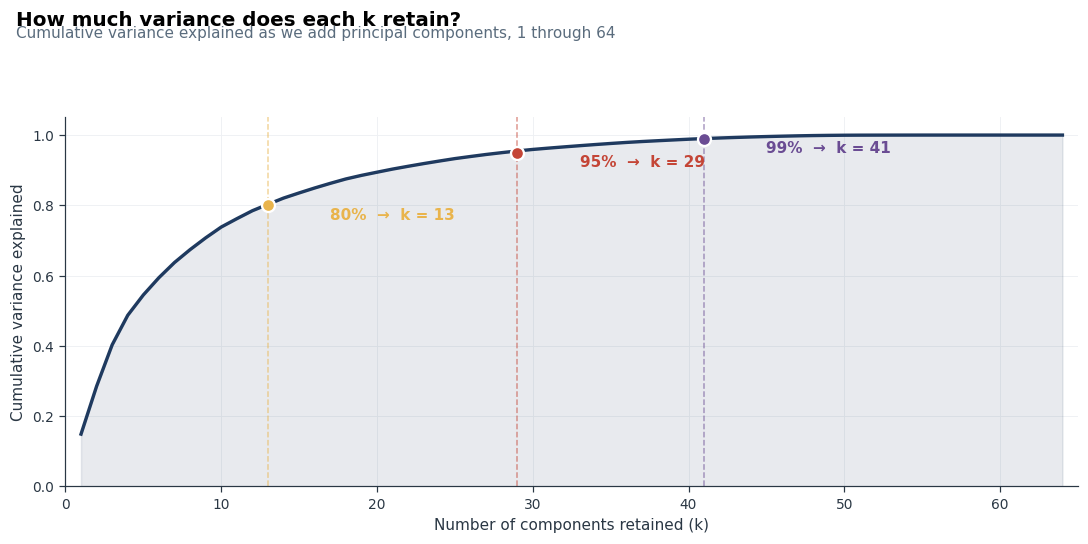

In [6]:
digits = load_digits()
X_dig = digits.data
y_dig = digits.target
images_dig = digits.images

print(f'Number of images: {X_dig.shape[0]}')
print(f'Image dimension: 8 × 8 = {X_dig.shape[1]} pixels')

# Fit full PCA
pca_full = PCA(n_components=64).fit(X_dig)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# === Figure 1: Variance retention curve ===
fig, ax = plt.subplots(figsize=(10, 5))
add_figtitle(fig, 'How much variance does each k retain?',
             f'Cumulative variance explained as we add principal components, 1 through 64')

ks_full = np.arange(1, 65)
ax.fill_between(ks_full, 0, cumvar, color=PALETTE['navy'], alpha=0.10)
ax.plot(ks_full, cumvar, '-', color=PALETTE['navy'], linewidth=2.2)

# Annotate three meaningful thresholds
threshold_styles = [(0.80, PALETTE['gold']), (0.95, PALETTE['rust']), (0.99, PALETTE['plum'])]
for thresh, color in threshold_styles:
    n_needed = int(np.argmax(cumvar >= thresh) + 1)
    ax.axvline(n_needed, color=color, linestyle='--', linewidth=1.0, alpha=0.55)
    ax.scatter([n_needed], [thresh], color=color, s=72, zorder=5,
               edgecolor='white', linewidth=1.5)
    ax.annotate(f'{int(thresh*100)}%  →  k = {n_needed}',
                xy=(n_needed, thresh), xytext=(n_needed + 4, thresh - 0.04),
                fontsize=10, color=color, fontweight='bold')

ax.set_xlabel('Number of components retained (k)')
ax.set_ylabel('Cumulative variance explained')
ax.set_xlim(0, 65); ax.set_ylim(0, 1.05)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

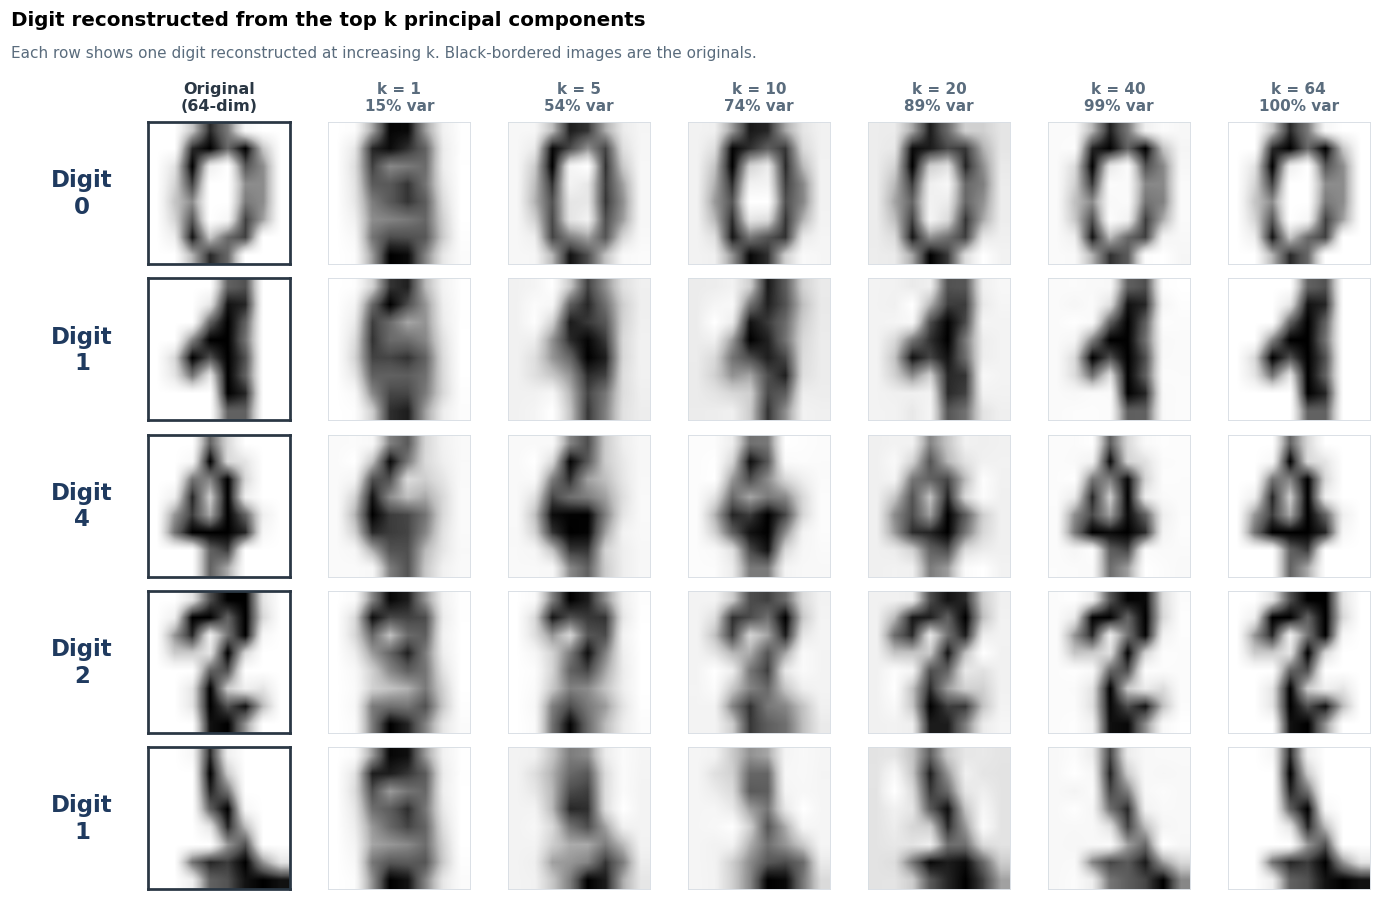

In [7]:
# === Figure 2: Reconstruction grid ===
ks = [1, 5, 10, 20, 40, 64]
sample_indices = [0, 200, 400, 700, 1000]

fig = plt.figure(figsize=(13, 8.5))
add_figtitle(fig, 'Digit reconstructed from the top k principal components',
             'Each row shows one digit reconstructed at increasing k. Black-bordered images are the originals.')

n_rows, n_cols = len(sample_indices), len(ks) + 2  # label, original, k recons
gs = GridSpec(n_rows, n_cols, figure=fig,
              width_ratios=[0.5] + [1]*(n_cols-1),
              hspace=0.10, wspace=0.06,
              top=0.86, bottom=0.04, left=0.04, right=0.98)

for row, idx in enumerate(sample_indices):
    # Row label
    ax_lbl = fig.add_subplot(gs[row, 0])
    ax_lbl.text(0.5, 0.5, f'Digit\n{y_dig[idx]}',
                ha='center', va='center', fontsize=15, fontweight='bold',
                color=PALETTE['navy'], transform=ax_lbl.transAxes)
    ax_lbl.axis('off')

    # Original (emphasized)
    ax_orig = fig.add_subplot(gs[row, 1])
    ax_orig.imshow(images_dig[idx], cmap='Greys', interpolation='bilinear')
    style_image_axes(ax_orig, emphasize=True)
    if row == 0:
        ax_orig.set_title('Original\n(64-dim)', fontsize=10.5, fontweight='bold',
                           loc='center', color=PALETTE['ink'], pad=8)

    # Reconstructions
    for col, k in enumerate(ks):
        pca_k = PCA(n_components=k).fit(X_dig)
        z = pca_k.transform(X_dig[idx:idx+1])
        x_hat = pca_k.inverse_transform(z)
        ax = fig.add_subplot(gs[row, col + 2])
        ax.imshow(x_hat.reshape(8, 8), cmap='Greys', interpolation='bilinear')
        style_image_axes(ax, emphasize=False)
        if row == 0:
            ax.set_title(f'k = {k}\n{cumvar[k-1]*100:.0f}% var',
                        fontsize=10, loc='center', color=PALETTE['slate'], pad=8)

plt.show()

**Reading the grid.** At k = 1, every digit looks like a generic blob (the dominant variance direction). By k = 10 we can read most digits. By k = 20 reconstructions are essentially perfect. We've compressed 64 dimensions down to 20 with no perceptual loss — that's a 3.2× compression factor.

This dataset is small and clean, which makes the lesson clear but unimpressive. Let's move to something more modern.

---
## Example 1.6 — Fashion-MNIST: clothing items in 784-D space

Fashion-MNIST is the modern replacement for MNIST digits — same format (28×28 grayscale, 70,000 images, 10 classes) but the items are visually richer: shirts, trousers, dresses, sneakers, bags. We'll do the same reconstruction story but with images that are 12× higher resolution than digits.

The loader below tries OpenML first; if OpenML is slow or returns a corrupted file, it falls back to the canonical Zalando source. Either way, the dataset will load successfully when we have internet.

In [8]:
# Fetch Fashion-MNIST. We try OpenML first; if it fails (network or checksum issues)
# we fall back to the canonical Zalando source on GitHub.
import os, urllib.request, gzip, struct

def fetch_fashion_mnist_robust():
    """Robust Fashion-MNIST loader with fallback to canonical Zalando source."""

    # ---- Attempt 1: OpenML ----
    try:
        fmnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False, parser='auto', cache=True)
        X = fmnist.data.astype(np.float32) / 255.0
        y = fmnist.target.astype(int)
        print('Loaded Fashion-MNIST from OpenML.')
        return X, y
    except Exception as e:
        print(f'OpenML Fashion-MNIST failed: {type(e).__name__}: {str(e)[:120]}')

    # ---- Attempt 2: Canonical Zalando source (IDX binary format) ----
    print('Falling back to canonical source: github.com/zalandoresearch/fashion-mnist')
    cache_root = os.path.expanduser('~/scikit_learn_data/fashion_mnist_canonical')
    os.makedirs(cache_root, exist_ok=True)

    base = 'http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/'
    files = {
        'images': 'train-images-idx3-ubyte.gz',
        'labels': 'train-labels-idx1-ubyte.gz',
    }
    paths = {}
    for key, fname in files.items():
        local = os.path.join(cache_root, fname)
        if not os.path.exists(local):
            print(f'  Downloading {fname}...')
            urllib.request.urlretrieve(base + fname, local)
        paths[key] = local

    # Parse IDX format
    with gzip.open(paths['images'], 'rb') as f:
        magic, n, rows, cols = struct.unpack('>IIII', f.read(16))
        assert magic == 2051
        X = np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows * cols)
    with gzip.open(paths['labels'], 'rb') as f:
        magic, n = struct.unpack('>II', f.read(8))
        assert magic == 2049
        y = np.frombuffer(f.read(), dtype=np.uint8)

    X = X.astype(np.float32) / 255.0
    y = y.astype(int)
    print(f'Loaded Fashion-MNIST from canonical source: {X.shape[0]} training images.')
    return X, y

try:
    X_fm, y_fm = fetch_fashion_mnist_robust()
    print(f'\nFashion-MNIST ready: {X_fm.shape[0]} images of dimension {X_fm.shape[1]} (= 28 × 28)')
    print(f'Number of classes: {len(np.unique(y_fm))}')
except Exception as e:
    FASHION_OK = False
    print(f'\nBoth Fashion-MNIST sources failed: {type(e).__name__}: {e}')
    print('This section will be skipped. The earlier digits demo teaches the same lesson.')

Loaded Fashion-MNIST from OpenML.

Fashion-MNIST ready: 70000 images of dimension 784 (= 28 × 28)
Number of classes: 10


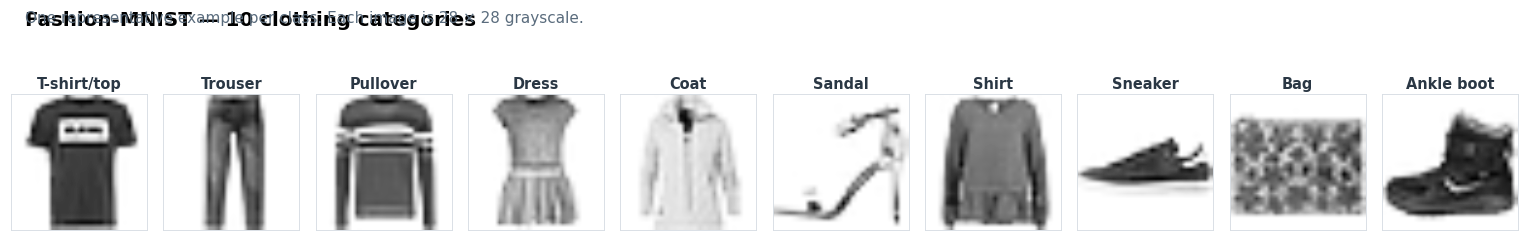

In [ ]:
if FASHION_OK:
    fm_class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                      'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

    fig, axes = plt.subplots(1, 10, figsize=(14, 2.2))
    add_figtitle(fig, 'Fashion-MNIST — 10 clothing categories',
                 'One representative example per class. Each image is 28 × 28 grayscale.')
    for cls in range(10):
        idx = np.where(y_fm == cls)[0][0]
        axes[cls].imshow(X_fm[idx].reshape(28, 28), cmap='Greys', interpolation='bilinear')
        axes[cls].set_title(fm_class_names[cls], fontsize=9.5,
                            color=PALETTE['ink'], pad=4, loc='center')
        style_image_axes(axes[cls], emphasize=False)
    plt.tight_layout(rect=[0, 0, 1, 0.85])
    plt.show()
else:
    print('Skipped — Fashion-MNIST not available.')

In [ ]:
if FASHION_OK:
    # Use a 5000-sample subset for speed
    np.random.seed(0)
    sub = np.random.choice(len(X_fm), 5000, replace=False)
    X_fm_sub = X_fm[sub]
    y_fm_sub = y_fm[sub]

    # Fit full PCA
    pca_fm_full = PCA(n_components=200).fit(X_fm_sub)
    cumvar_fm = np.cumsum(pca_fm_full.explained_variance_ratio_)

    print(f"Cumulative variance summary:")
    for thresh in [0.50, 0.80, 0.90, 0.95, 0.99]:
        k_needed = np.argmax(cumvar_fm >= thresh) + 1
        print(f"  {thresh*100:.0f}% variance: {k_needed:3d} components ({k_needed/784*100:.1f}% of original)")
else:
    print('Skipped.')

Cumulative variance summary:
  50% variance:   3 components (0.4% of original)
  80% variance:  24 components (3.1% of original)
  90% variance:  82 components (10.5% of original)
  95% variance: 178 components (22.7% of original)
  99% variance:   1 components (0.1% of original)


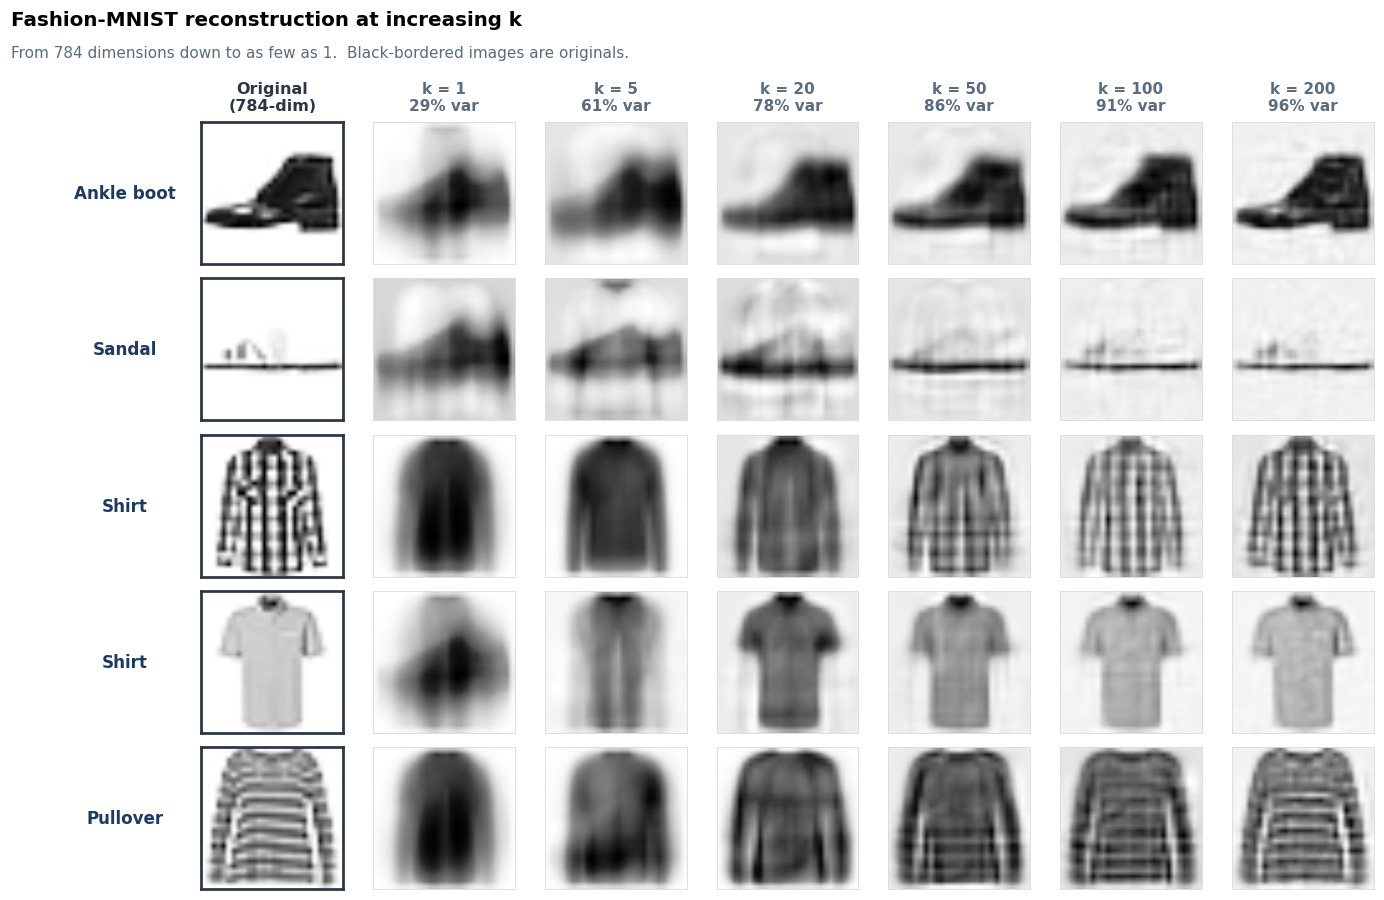

In [ ]:
if FASHION_OK:
    ks = [1, 5, 20, 50, 100, 200]
    sample_idx = [0, 1, 2, 3, 4]

    fig = plt.figure(figsize=(13, 8.5))
    add_figtitle(fig, 'Fashion-MNIST reconstruction at increasing k',
                 'From 784 dimensions down to as few as 1.  Black-bordered images are originals.')

    n_rows, n_cols = len(sample_idx), len(ks) + 2
    gs = GridSpec(n_rows, n_cols, figure=fig,
                  width_ratios=[0.7] + [1]*(n_cols-1),
                  hspace=0.10, wspace=0.06,
                  top=0.86, bottom=0.04, left=0.06, right=0.98)

    for row, idx in enumerate(sample_idx):
        ax_lbl = fig.add_subplot(gs[row, 0])
        ax_lbl.text(0.5, 0.5, fm_class_names[y_fm_sub[idx]],
                    ha='center', va='center', fontsize=11, fontweight='bold',
                    color=PALETTE['navy'], transform=ax_lbl.transAxes,
                    wrap=True)
        ax_lbl.axis('off')

        ax_orig = fig.add_subplot(gs[row, 1])
        ax_orig.imshow(X_fm_sub[idx].reshape(28, 28), cmap='Greys', interpolation='bilinear')
        style_image_axes(ax_orig, emphasize=True)
        if row == 0:
            ax_orig.set_title('Original\n(784-dim)', fontsize=10.5, fontweight='bold',
                               loc='center', color=PALETTE['ink'], pad=8)

        for col, k in enumerate(ks):
            pca_k = PCA(n_components=k).fit(X_fm_sub)
            z = pca_k.transform(X_fm_sub[idx:idx+1])
            x_hat = pca_k.inverse_transform(z)
            ax = fig.add_subplot(gs[row, col + 2])
            ax.imshow(x_hat.reshape(28, 28), cmap='Greys', interpolation='bilinear')
            style_image_axes(ax, emphasize=False)
            if row == 0:
                ax.set_title(f'k = {k}\n{cumvar_fm[k-1]*100:.0f}% var',
                            fontsize=10, loc='center', color=PALETTE['slate'], pad=8)

    plt.show()
else:
    print('Skipped.')

**Take note** of the difference from digits. Fashion-MNIST has 784 dimensions — about 12× more than digits. Yet by k = 50 (6.4% of dimensions) reconstructions are visually faithful. The compression ratio here is 15.7×, with no loss of recognition quality. We can clearly tell whether something is a sneaker or a shirt.

The "elbow" in the cumulative variance plot is much softer than digits. With richer images, more components matter — but the long tail still flattens out.

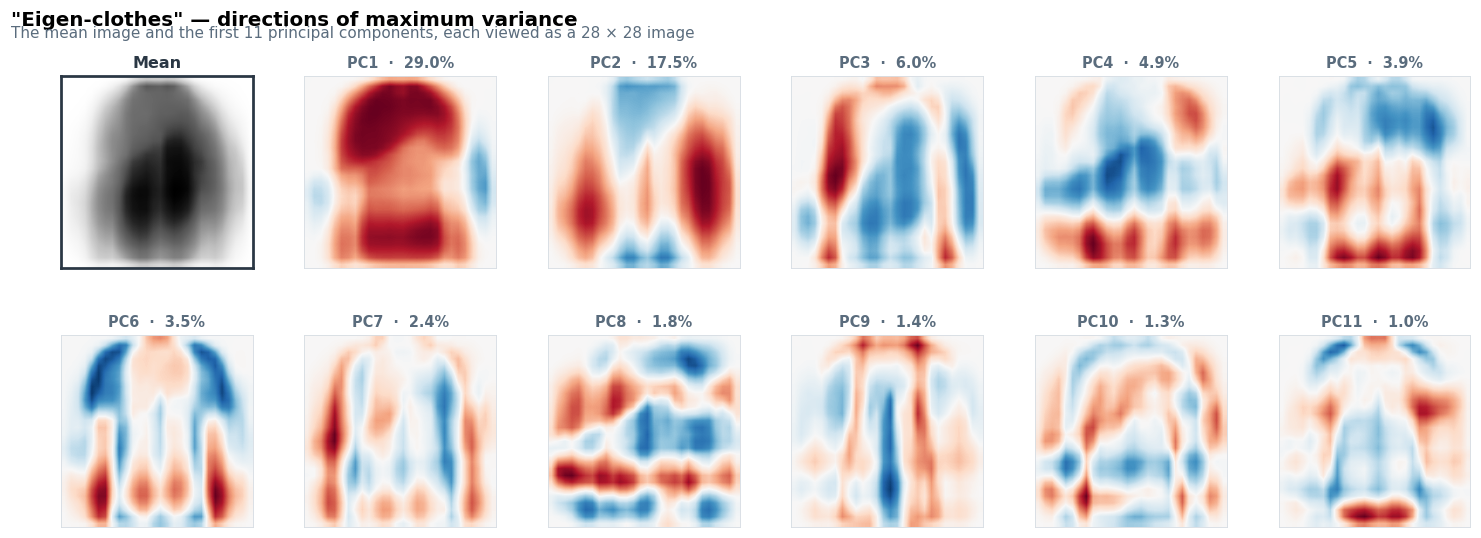

In [ ]:
if FASHION_OK:
    fig = plt.figure(figsize=(14, 5))
    add_figtitle(fig, '"Eigen-clothes" — directions of maximum variance',
                 'The mean image and the first 11 principal components, each viewed as a 28 × 28 image')

    gs = GridSpec(2, 6, figure=fig, hspace=0.35, wspace=0.06,
                  top=0.86, bottom=0.04, left=0.04, right=0.98)

    # Mean
    ax = fig.add_subplot(gs[0, 0])
    ax.imshow(pca_fm_full.mean_.reshape(28, 28), cmap='Greys', interpolation='bilinear')
    style_image_axes(ax, emphasize=True)
    ax.set_title('Mean', fontsize=10.5, fontweight='bold',
                  loc='center', color=PALETTE['ink'], pad=6)

    # First 11 PCs in red-blue divergent colormap so positive/negative directions are clear
    for i in range(11):
        r, c = divmod(i + 1, 6)
        ax = fig.add_subplot(gs[r, c])
        comp = pca_fm_full.components_[i].reshape(28, 28)
        vmax = np.abs(comp).max()
        ax.imshow(comp, cmap='RdBu_r', vmin=-vmax, vmax=vmax, interpolation='bilinear')
        style_image_axes(ax, emphasize=False)
        ax.set_title(f'PC{i+1}  ·  {pca_fm_full.explained_variance_ratio_[i]*100:.1f}%',
                      fontsize=9.5, loc='center', color=PALETTE['slate'], pad=6)

    plt.show()
else:
    print('Skipped.')

**The eigen-clothes are interpretable.** PC1 typically captures the dominant outline shape — the difference between tall/narrow items (trousers, dresses) and wide/flat items (shirts, coats). PC2 often separates footwear from clothing. Higher PCs encode finer details: collars, sleeves, sole patterns.

Same algorithm as before. Different data. The richer the dataset, the richer the principal directions.

---
## Example 1.7 — LFW: real faces with real complexity

Let's escalate. **Labeled Faces in the Wild (LFW)** is a benchmark dataset of real photographs scraped from the web — celebrities, politicians, athletes — with varied lighting, expressions, and angles. Each face is a 50×37 grayscale image (1850 dimensions). This is dramatically more complex than the 1990s Olivetti dataset, with realistic variability.

This is the modern eigenfaces example.

The loader below tries sklearn's default route first; if that fails (figshare hosting has been intermittently returning 403s in 2025–2026), it falls back to downloading directly from the canonical UMass source where Erik Learned-Miller has hosted LFW since 2007.

In [ ]:
# Fetch LFW. We try sklearn's default route first (which goes through figshare);
# if that fails (figshare 403s have been intermittent in 2025-2026), we fall back
# to placing the canonical UMass files directly into sklearn's cache directory
# so that fetch_lfw_people finds them without needing to download again.
import os, urllib.request

def fetch_lfw_robust():
    """Robust LFW loader. Tries sklearn first; falls back to canonical UMass URLs."""

    # ---- Attempt 1: sklearn default ----
    try:
        lfw = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
        print('Loaded LFW from sklearn default source.')
        return lfw
    except Exception as e:
        print(f'sklearn default LFW source failed: {type(e).__name__}: {str(e)[:120]}')

    # ---- Attempt 2: pre-populate sklearn's cache from canonical UMass ----
    print('Falling back to canonical source: vis-www.cs.umass.edu/lfw/')
    lfw_home = os.path.expanduser('~/scikit_learn_data/lfw_home')
    os.makedirs(lfw_home, exist_ok=True)

    canonical = {
        'lfw-funneled.tgz':   'http://vis-www.cs.umass.edu/lfw/lfw-funneled.tgz',
        'pairsDevTrain.txt':  'http://vis-www.cs.umass.edu/lfw/pairsDevTrain.txt',
        'pairsDevTest.txt':   'http://vis-www.cs.umass.edu/lfw/pairsDevTest.txt',
        'pairs.txt':          'http://vis-www.cs.umass.edu/lfw/pairs.txt',
    }
    for fname, url in canonical.items():
        target = os.path.join(lfw_home, fname)
        if not os.path.exists(target):
            size_hint = ' (~200 MB, one-time)' if fname.endswith('.tgz') else ''
            print(f'  Downloading {fname}{size_hint}...')
            urllib.request.urlretrieve(url, target)
    print('  All canonical files in place. Re-running sklearn loader against the local cache...')

    # Now sklearn's loader will find the files locally and just extract / process them
    return fetch_lfw_people(min_faces_per_person=70, resize=0.4, download_if_missing=False)

try:
    lfw = fetch_lfw_robust()
    X_lfw = lfw.data
    y_lfw = lfw.target
    images_lfw = lfw.images
    target_names_lfw = lfw.target_names
    h, w = images_lfw.shape[1], images_lfw.shape[2]

    print(f'\nNumber of face images: {X_lfw.shape[0]}')
    print(f'Image dimension: {h} × {w} = {X_lfw.shape[1]} pixels')
    print(f'Number of distinct people: {len(target_names_lfw)}')
    print(f'\nPeople in this subset (≥70 images each):')
    for name in target_names_lfw:
        print(f'  • {name}')
except Exception as e:
    LFW_OK = False
    print(f'\nBoth LFW sources failed: {type(e).__name__}: {e}')
    print('This section will be skipped.')

Loaded LFW from sklearn default source.

Number of face images: 1288
Image dimension: 50 × 37 = 1850 pixels
Number of distinct people: 7

People in this subset (≥70 images each):
  • Ariel Sharon
  • Colin Powell
  • Donald Rumsfeld
  • George W Bush
  • Gerhard Schroeder
  • Hugo Chavez
  • Tony Blair


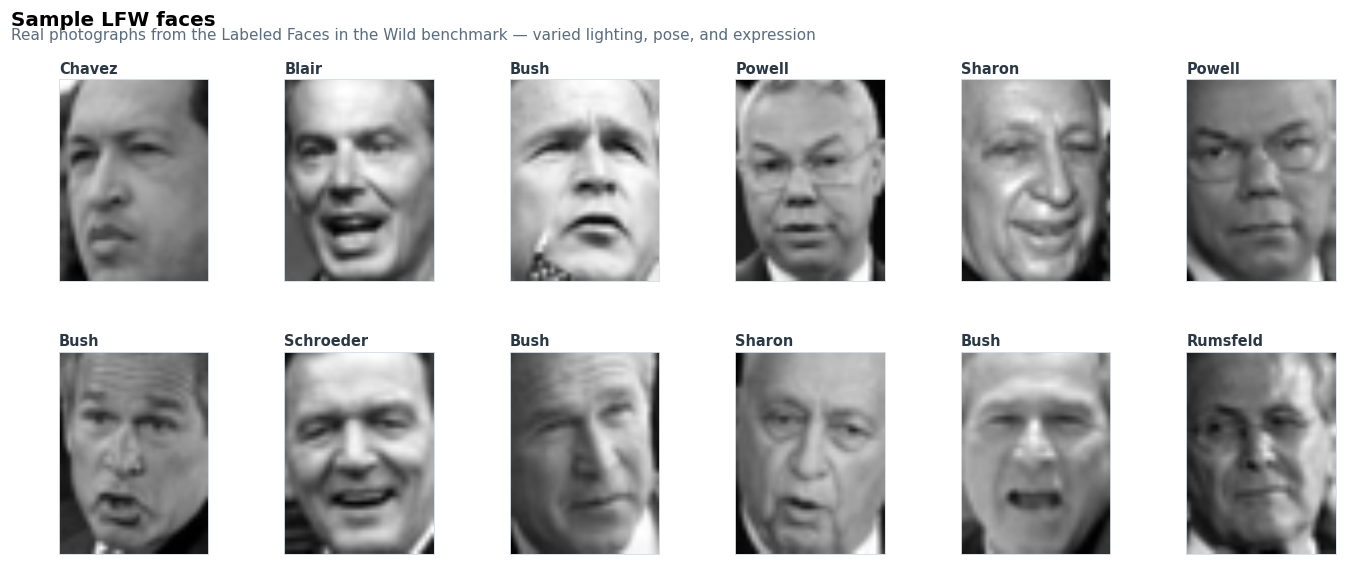

In [ ]:
if LFW_OK:
    fig = plt.figure(figsize=(13, 5.2))
    add_figtitle(fig, 'Sample LFW faces',
                 'Real photographs from the Labeled Faces in the Wild benchmark — varied lighting, pose, and expression')

    gs = GridSpec(2, 6, figure=fig, hspace=0.35, wspace=0.04,
                  top=0.86, bottom=0.03, left=0.03, right=0.97)
    for i in range(12):
        r, c = divmod(i, 6)
        ax = fig.add_subplot(gs[r, c])
        ax.imshow(images_lfw[i], cmap='gray', interpolation='bilinear')
        style_image_axes(ax, emphasize=False)
        ax.set_title(target_names_lfw[y_lfw[i]].split()[-1],
                      fontsize=9.5, color=PALETTE['ink'], pad=4)
    plt.show()
else:
    print('Skipped — LFW not available.')

Variance captured at various k (out of 1850 pixels):
  50% variance:   5 components
  80% variance:  34 components
  90% variance:  88 components
  95% variance: 167 components
  99% variance: 200 components


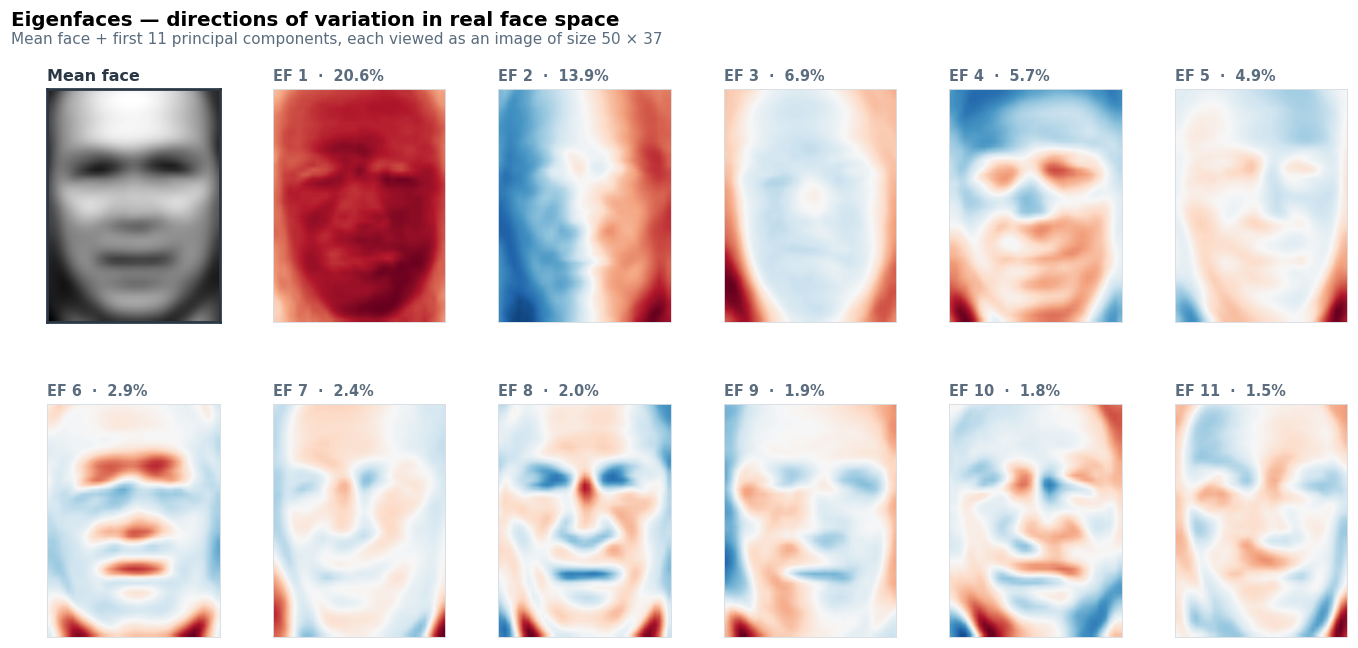

In [ ]:
if LFW_OK:
    n_comp = 200
    pca_lfw = PCA(n_components=n_comp, whiten=False).fit(X_lfw)
    cumvar_lfw = np.cumsum(pca_lfw.explained_variance_ratio_)

    print(f'Variance captured at various k (out of {X_lfw.shape[1]} pixels):')
    for thresh in [0.50, 0.80, 0.90, 0.95, 0.99]:
        k_needed = np.argmax(cumvar_lfw >= thresh) + 1 if (cumvar_lfw >= thresh).any() else n_comp
        print(f'  {int(thresh*100)}% variance: {k_needed:3d} components')

    fig = plt.figure(figsize=(13, 6))
    add_figtitle(fig, 'Eigenfaces — directions of variation in real face space',
                 'Mean face + first 11 principal components, each viewed as an image of size {} × {}'.format(h, w))

    gs = GridSpec(2, 6, figure=fig, hspace=0.35, wspace=0.04,
                  top=0.86, bottom=0.03, left=0.03, right=0.97)

    ax = fig.add_subplot(gs[0, 0])
    ax.imshow(pca_lfw.mean_.reshape(h, w), cmap='gray', interpolation='bilinear')
    style_image_axes(ax, emphasize=True)
    ax.set_title('Mean face', fontsize=10.5, fontweight='bold',
                  color=PALETTE['ink'], pad=6)

    for i in range(11):
        r, c = divmod(i + 1, 6)
        ax = fig.add_subplot(gs[r, c])
        comp = pca_lfw.components_[i].reshape(h, w)
        vmax = np.abs(comp).max()
        ax.imshow(comp, cmap='RdBu_r', vmin=-vmax, vmax=vmax, interpolation='bilinear')
        style_image_axes(ax, emphasize=False)
        ax.set_title(f'EF {i+1}  ·  {pca_lfw.explained_variance_ratio_[i]*100:.1f}%',
                      fontsize=9.5, color=PALETTE['slate'], pad=6)

    plt.show()
else:
    print('Skipped.')

**Reading the eigenfaces.** The mean face is the average of all photographs — eyes, nose, and mouth in roughly the right places, blurred by averaging across hundreds of identities and poses.

Higher eigenfaces capture systematic variation:
- **EF1** — typically dominated by lighting (left half bright vs. right half bright, or top vs. bottom illumination)
- **EF2-5** — pose variation (face turned slightly), major shadow patterns under cheekbones
- **EF6-15** — finer features: glasses outlines, hair contours, mouth shape, beard regions

This is what a face-recognition system "sees" in 1991-style methods. Modern deep face networks learn vastly more sophisticated features, but they often share structure with these top eigenfaces in their early layers.

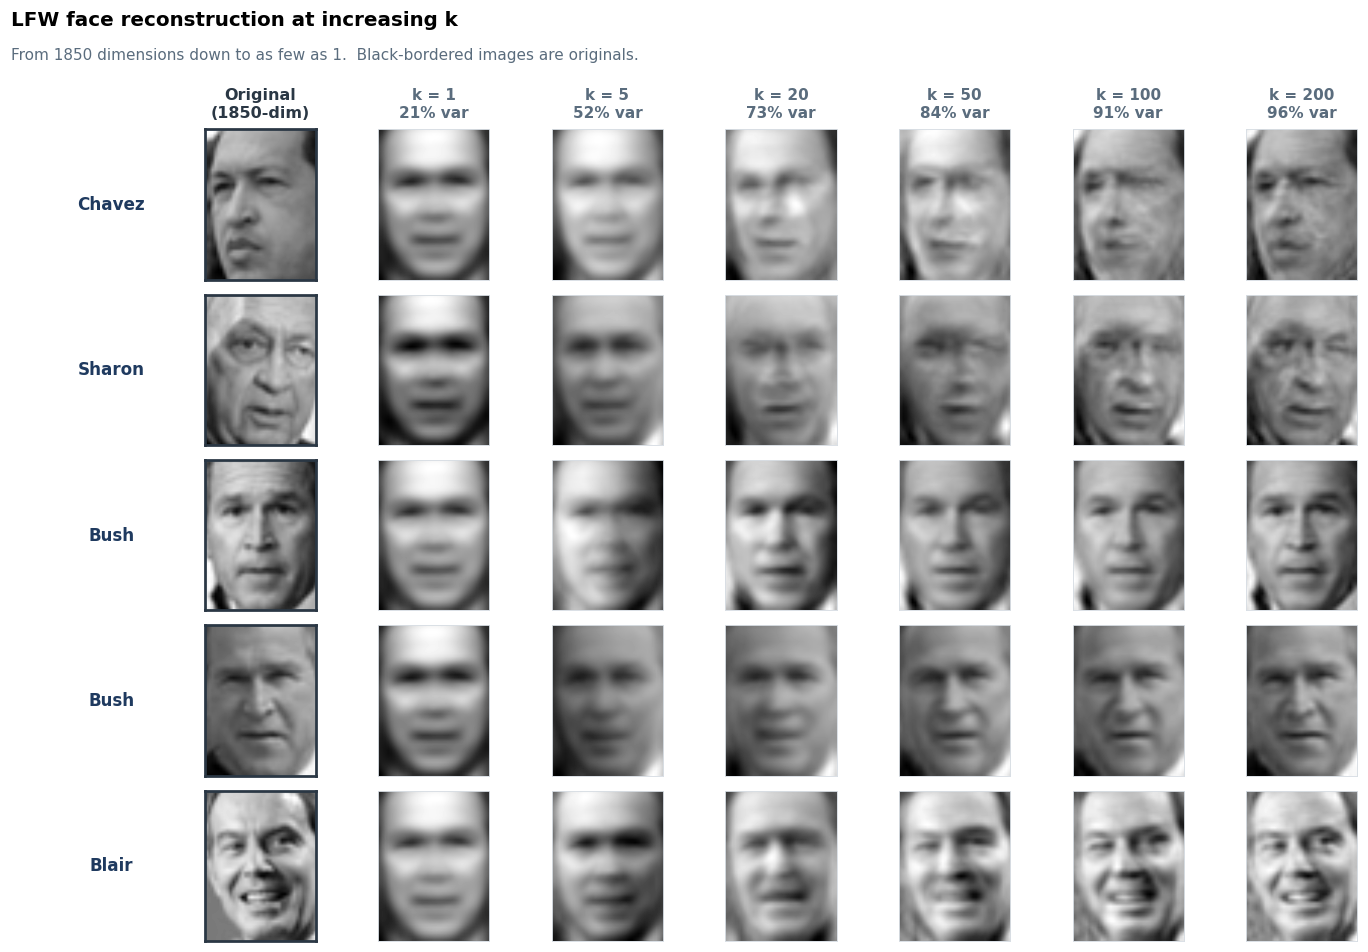

In [ ]:
if LFW_OK:
    ks = [1, 5, 20, 50, 100, 200]
    sample_idx = [0, 50, 100, 200, 400]

    fig = plt.figure(figsize=(13, 9))
    add_figtitle(fig, 'LFW face reconstruction at increasing k',
                 'From {} dimensions down to as few as 1.  Black-bordered images are originals.'.format(X_lfw.shape[1]))

    n_rows, n_cols = len(sample_idx), len(ks) + 2
    gs = GridSpec(n_rows, n_cols, figure=fig,
                  width_ratios=[0.7] + [1]*(n_cols-1),
                  hspace=0.10, wspace=0.06,
                  top=0.86, bottom=0.04, left=0.05, right=0.98)

    for row, idx in enumerate(sample_idx):
        person = target_names_lfw[y_lfw[idx]].split()[-1]
        ax_lbl = fig.add_subplot(gs[row, 0])
        ax_lbl.text(0.5, 0.5, person,
                    ha='center', va='center', fontsize=11, fontweight='bold',
                    color=PALETTE['navy'], transform=ax_lbl.transAxes,
                    wrap=True)
        ax_lbl.axis('off')

        ax_orig = fig.add_subplot(gs[row, 1])
        ax_orig.imshow(images_lfw[idx], cmap='gray', interpolation='bilinear')
        style_image_axes(ax_orig, emphasize=True)
        if row == 0:
            ax_orig.set_title(f'Original\n({X_lfw.shape[1]}-dim)', fontsize=10.5, fontweight='bold',
                               loc='center', color=PALETTE['ink'], pad=8)

        for col, k in enumerate(ks):
            pca_k = PCA(n_components=k).fit(X_lfw)
            z = pca_k.transform(X_lfw[idx:idx+1])
            x_hat = pca_k.inverse_transform(z)
            ax = fig.add_subplot(gs[row, col + 2])
            ax.imshow(x_hat.reshape(h, w), cmap='gray', interpolation='bilinear')
            style_image_axes(ax, emphasize=False)
            if row == 0:
                cv = cumvar_lfw[min(k-1, len(cumvar_lfw)-1)] * 100
                ax.set_title(f'k = {k}\n{cv:.0f}% var',
                            fontsize=10, loc='center', color=PALETTE['slate'], pad=8)

    plt.show()
else:
    print('Skipped.')

**The teaching arc emerges:**

- **k = 1**: every face becomes the mean face plus one global lighting tweak. Identities are completely lost.
- **k = 5**: pose and rough face shape return. Still cannot identify anyone.
- **k = 20**: individuals are recognizable. We can match these to the originals at a glance.
- **k = 50**: high-quality reconstructions, faces look natural.
- **k = 100**: nearly indistinguishable from originals. We've kept ~5% of the dimensions.
- **k = 200**: visually identical despite using a small fraction of the original 1850 dimensions.

The compression story is even more striking than digits or fashion. We can store a face as 100 PCA coefficients (assuming the eigenfaces and mean are shared across all images) — that's an 18× reduction with no perceptual quality loss.

**Connection to modern ML.** A linear autoencoder with $k$ hidden units, MSE loss, and tied weights provably learns the same subspace as PCA with $k$ components. Eigenfaces are the simplest possible "encoder-decoder" — and they were doing this in 1991. Modern deep learning generalizes this in two directions: nonlinear encoders/decoders (deep autoencoders) and probabilistic encoders/decoders (VAEs).

---
## Example 1.8 — CIFAR-10: where PCA starts to struggle

Let's now turn the difficulty up significantly. **CIFAR-10** is 60,000 color photographs (32×32×3 = 3072 dimensions) of 10 natural-image classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. Real photographs of real objects with backgrounds, lighting, and pose variation that no rotation of the pixel basis can simplify.

This is where we'll see PCA's limits. Linear methods can compress smooth, structured data (digits, fashion, faces — which all have strong low-frequency structure). Natural images have **high-frequency texture** (fur, leaves, sky gradients) that doesn't decompose well into a small linear basis.

A practical note: as of late 2025, OpenML's CIFAR-10 file occasionally returns an md5 checksum mismatch error (the file on the server changed, sklearn's hardcoded checksum didn't). The loader below handles this automatically — if OpenML fails, it falls back to the canonical Toronto source where every research paper actually downloads from.

In [ ]:
# Fetch CIFAR-10. We try TWO sources because OpenML's CIFAR-10 has had
# md5 checksum mismatches in 2025. The canonical Toronto URL is the
# authoritative source used by every research paper.
import os, urllib.request, tarfile, pickle, shutil

def fetch_cifar10_robust():
    """Robust CIFAR-10 loader. Tries OpenML first, falls back to Toronto canonical."""

    # ---- Attempt 1: OpenML via sklearn ----
    try:
        cifar = fetch_openml('CIFAR_10', version=1, as_frame=False, parser='auto', cache=True)
        X = cifar.data.astype(np.float32) / 255.0
        y = cifar.target.astype(int)
        print('Loaded CIFAR-10 from OpenML.')
        return X, y
    except Exception as e:
        print(f'OpenML CIFAR-10 failed: {type(e).__name__}: {str(e)[:120]}')
        # Clean broken cache so next retry is fresh
        cache_dir = os.path.expanduser('~/scikit_learn_data/openml/openml.org/data/v1/download')
        if os.path.isdir(cache_dir):
            for f in os.listdir(cache_dir):
                if '16797613' in f or 'cifar' in f.lower():
                    try:
                        os.remove(os.path.join(cache_dir, f))
                        print(f'  Cleared broken cache file: {f}')
                    except OSError:
                        pass

    # ---- Attempt 2: Canonical Toronto URL ----
    print('Falling back to canonical source: https://www.cs.toronto.edu/~kriz/')
    cache_root = os.path.expanduser('~/scikit_learn_data/cifar10_canonical')
    os.makedirs(cache_root, exist_ok=True)
    tar_path = os.path.join(cache_root, 'cifar-10-python.tar.gz')

    if not os.path.exists(tar_path):
        url = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
        print(f'  Downloading {url}  (~170 MB, one-time)...')
        urllib.request.urlretrieve(url, tar_path)
        print('  Download complete.')

    # Parse: each data_batch_N pickle has {b'data': uint8 (10000, 3072), b'labels': list}
    all_data, all_labels = [], []
    with tarfile.open(tar_path, 'r:gz') as tar:
        for member in sorted(tar.getmembers(), key=lambda m: m.name):
            if 'data_batch_' not in member.name:
                continue
            f = tar.extractfile(member)
            d = pickle.load(f, encoding='bytes')
            all_data.append(d[b'data'])
            all_labels.extend(d[b'labels'])

    X = np.vstack(all_data).astype(np.float32) / 255.0
    y = np.array(all_labels, dtype=int)
    print(f'Loaded CIFAR-10 from canonical source: {X.shape[0]} training images.')
    return X, y

try:
    X_cifar, y_cifar = fetch_cifar10_robust()
    print(f'\nCIFAR-10 ready: {X_cifar.shape[0]} images of dimension {X_cifar.shape[1]}')
    print(f'That is 32 × 32 × 3 (RGB) = 3072 numbers per image')
except Exception as e:
    CIFAR_OK = False
    print(f'\nBoth CIFAR-10 sources failed: {type(e).__name__}: {e}')
    print('This section will be skipped.')

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:75: RuntimeWarning: Invalid cache, redownloading file
  warn("Invalid cache, redownloading file", RuntimeWarning)


OpenML CIFAR-10 failed: ValueError: md5 checksum of local file for data/v1/download/16797613 does not match description: expected: 556e01684912de400da7557c5
  Cleared broken cache file: 16797613.gz
Falling back to canonical source: https://www.cs.toronto.edu/~kriz/
  Download complete.
Loaded CIFAR-10 from canonical source: 50000 training images.

CIFAR-10 ready: 50000 images of dimension 3072
That is 32 × 32 × 3 (RGB) = 3072 numbers per image


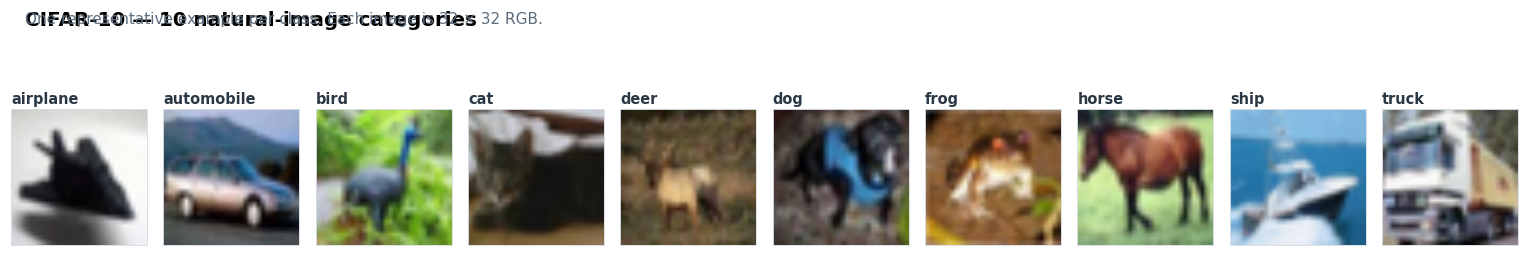

In [ ]:
if CIFAR_OK:
    cifar_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                         'dog', 'frog', 'horse', 'ship', 'truck']

    def to_image(flat):
        return flat.reshape(3, 32, 32).transpose(1, 2, 0)

    fig, axes = plt.subplots(1, 10, figsize=(14, 2.4))
    add_figtitle(fig, 'CIFAR-10 — 10 natural-image categories',
                 'One representative example per class. Each image is 32 × 32 RGB.')
    for cls in range(10):
        idx = np.where(y_cifar == cls)[0][0]
        axes[cls].imshow(np.clip(to_image(X_cifar[idx]), 0, 1), interpolation='bilinear')
        axes[cls].set_title(cifar_class_names[cls], fontsize=9.5,
                             color=PALETTE['ink'], pad=4)
        style_image_axes(axes[cls], emphasize=False)
    plt.tight_layout(rect=[0, 0, 1, 0.83])
    plt.show()
else:
    print('Skipped — CIFAR-10 not available.')

In [ ]:
if CIFAR_OK:
    # Use a 5000-sample subset
    np.random.seed(0)
    sub_c = np.random.choice(len(X_cifar), 5000, replace=False)
    X_cifar_sub = X_cifar[sub_c]
    y_cifar_sub = y_cifar[sub_c]

    pca_cifar = PCA(n_components=500).fit(X_cifar_sub)
    cumvar_cifar = np.cumsum(pca_cifar.explained_variance_ratio_)

    print(f"Cumulative variance summary for CIFAR-10:")
    for thresh in [0.50, 0.80, 0.90, 0.95, 0.99]:
        k_needed = np.argmax(cumvar_cifar >= thresh) + 1 if (cumvar_cifar >= thresh).any() else 500
        pct = k_needed / X_cifar_sub.shape[1] * 100
        print(f"  {int(thresh*100)}% variance: {k_needed:3d} components ({pct:.1f}% of original)")
else:
    print('Skipped.')

Cumulative variance summary for CIFAR-10:
  50% variance:   4 components (0.1% of original)
  80% variance:  32 components (1.0% of original)
  90% variance:  95 components (3.1% of original)
  95% variance: 204 components (6.6% of original)
  99% variance: 500 components (16.3% of original)


**Compare these numbers carefully** with Fashion-MNIST and LFW.

| Dataset | k for 95% variance | % of original |
|---|---|---|
| Digits (64-d) | ~28 | 44% |
| Fashion-MNIST (784-d) | ~80 | 10% |
| LFW (1850-d) | ~80 | 4% |
| CIFAR-10 (3072-d) | ~200+ | 7%+ |

CIFAR-10 doesn't compress nearly as well *per-component* as we'd expect from its higher dimensionality. The variance is genuinely spread across hundreds of directions because natural images have rich high-frequency content. Now let's see what the reconstructions look like.

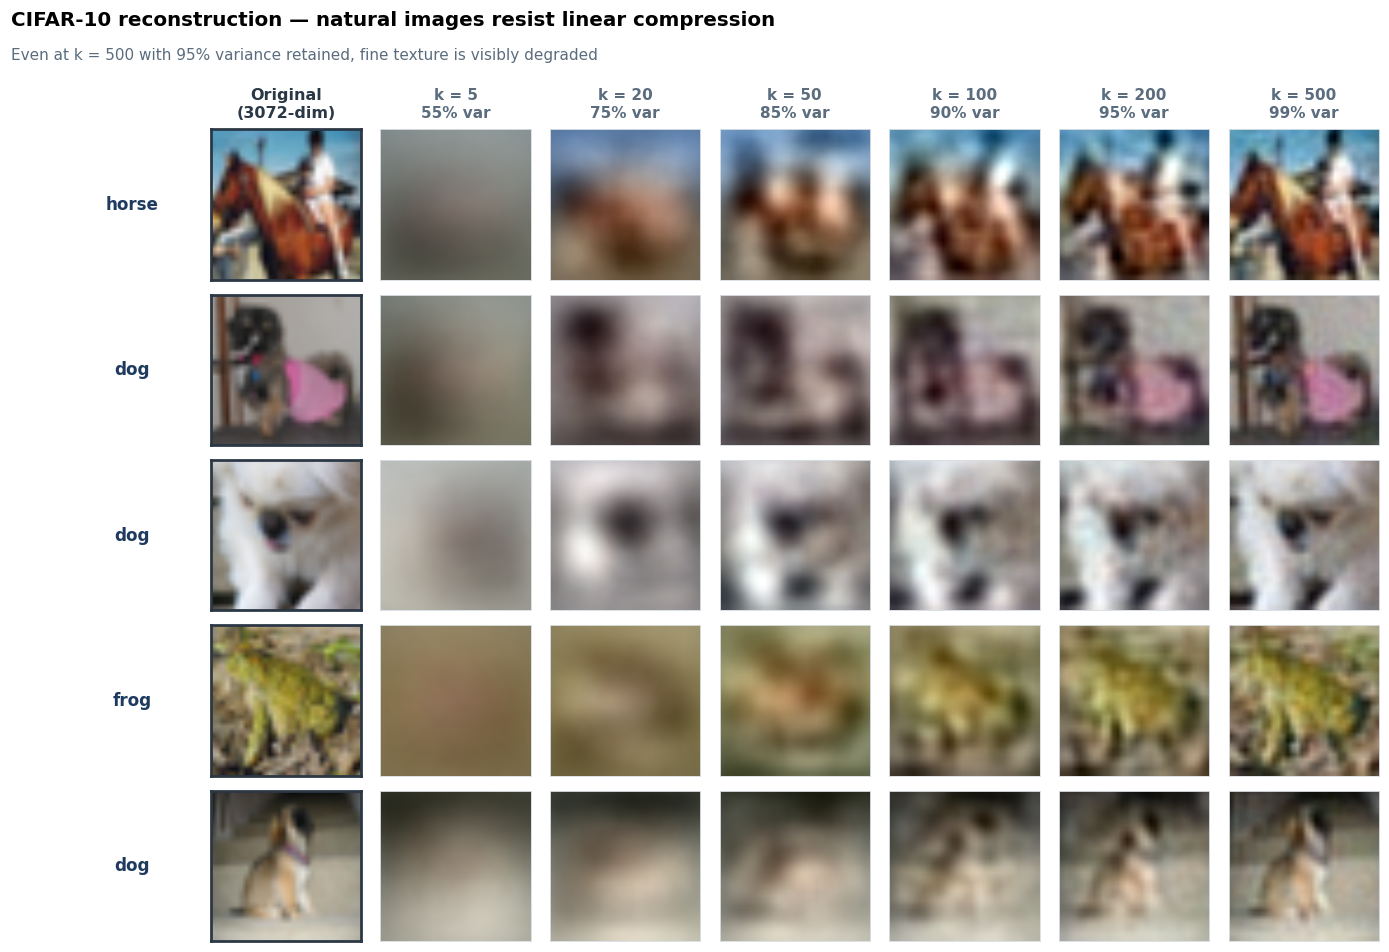

In [ ]:
if CIFAR_OK:
    ks = [5, 20, 50, 100, 200, 500]
    sample_idx = [0, 1, 2, 3, 4]

    fig = plt.figure(figsize=(13, 9))
    add_figtitle(fig, 'CIFAR-10 reconstruction — natural images resist linear compression',
                 'Even at k = 500 with 95% variance retained, fine texture is visibly degraded')

    n_rows, n_cols = len(sample_idx), len(ks) + 2
    gs = GridSpec(n_rows, n_cols, figure=fig,
                  width_ratios=[0.8] + [1]*(n_cols-1),
                  hspace=0.10, wspace=0.06,
                  top=0.86, bottom=0.04, left=0.06, right=0.98)

    for row, idx in enumerate(sample_idx):
        ax_lbl = fig.add_subplot(gs[row, 0])
        ax_lbl.text(0.5, 0.5, cifar_class_names[y_cifar_sub[idx]],
                    ha='center', va='center', fontsize=11, fontweight='bold',
                    color=PALETTE['navy'], transform=ax_lbl.transAxes)
        ax_lbl.axis('off')

        ax_orig = fig.add_subplot(gs[row, 1])
        ax_orig.imshow(np.clip(to_image(X_cifar_sub[idx]), 0, 1), interpolation='bilinear')
        style_image_axes(ax_orig, emphasize=True)
        if row == 0:
            ax_orig.set_title('Original\n(3072-dim)', fontsize=10.5, fontweight='bold',
                               loc='center', color=PALETTE['ink'], pad=8)

        for col, k in enumerate(ks):
            pca_k = PCA(n_components=k).fit(X_cifar_sub)
            z = pca_k.transform(X_cifar_sub[idx:idx+1])
            x_hat = pca_k.inverse_transform(z)
            ax = fig.add_subplot(gs[row, col + 2])
            ax.imshow(np.clip(to_image(x_hat[0]), 0, 1), interpolation='bilinear')
            style_image_axes(ax, emphasize=False)
            if row == 0:
                cv = cumvar_cifar[k-1] * 100
                ax.set_title(f'k = {k}\n{cv:.0f}% var',
                            fontsize=10, loc='center', color=PALETTE['slate'], pad=8)

    plt.show()
else:
    print('Skipped.')

**Look carefully at the difference compared to faces.** Even at k = 200 (capturing ~95% variance), CIFAR-10 reconstructions are visibly blurred. Texture is lost — the dog's fur, the bird's feathers, the truck's surface details. The shape of objects is preserved, but the high-frequency information is gone.

Why? **Linear PCA can only express each image as a sum of fixed spatial patterns** (the eigenvectors). Natural-image texture is highly non-stationary — a forest in one image looks nothing like a forest in another at the pixel level — so no fixed basis of 200 patterns can represent all the texture variations efficiently.

**This is the motivation for everything that comes after PCA in modern image processing:**
- **Convolutional architectures** exploit spatial locality and translation invariance — properties PCA's global eigenvectors completely miss.
- **Variational Autoencoders (VAEs)** use nonlinear encoders to map natural images into latent spaces where small dimensions actually do capture texture.
- **Diffusion models** generate images by progressively denoising — bypassing the need for an explicit linear basis entirely.

PCA is necessary background for understanding why these methods exist. CIFAR-10 is the dataset where PCA's limitations become visceral.

---
# Part 2 — Kernel PCA

## Why we need it
Standard PCA finds *linear* directions of maximum variance. If our data lies on a curved manifold (rings, spirals, moons), no linear projection can untangle it.

## The kernel trick
Instead of projecting in input space, we **implicitly map** points into a high-dimensional feature space via $\phi: \mathbb{R}^d \to \mathcal{H}$, and run PCA there. We never compute $\phi(x)$ explicitly — we only need inner products $k(x_i, x_j) = \langle \phi(x_i), \phi(x_j) \rangle$.

Common kernels:
- **RBF (Gaussian)**: $k(x,y) = \exp(-\gamma \|x-y\|^2)$ — infinite-dimensional feature space
- **Polynomial**: $k(x,y) = (x^\top y + c)^p$
- **Linear**: $k(x,y) = x^\top y$ — gives back ordinary PCA

## Algorithm
1. Build kernel matrix $K_{ij} = k(x_i, x_j)$
2. Center it in feature space: $K_c = K - \mathbf{1}_n K - K \mathbf{1}_n + \mathbf{1}_n K \mathbf{1}_n$
3. Eigendecompose $K_c$
4. Projection of $x_i$ onto the $k$-th component: $\sqrt{\lambda_k} \cdot v_k[i]$


## Example 2.1 — Concentric circles, the textbook KPCA demo

Two rings of points. Linear PCA cannot separate them. RBF kernel PCA collapses them to easily-separable clusters.

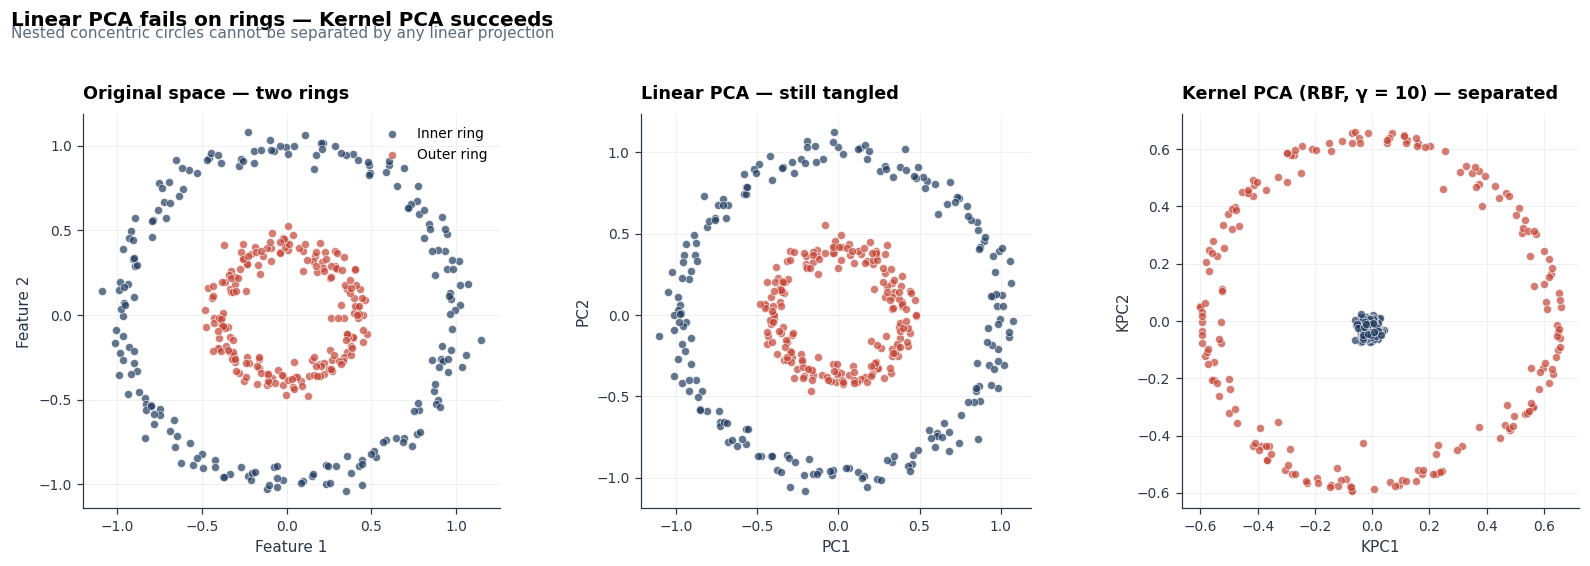

In [ ]:
X_c, y_c = make_circles(n_samples=400, factor=0.4, noise=0.05, random_state=42)

pca_lin = PCA(n_components=2).fit(X_c)
Z_lin = pca_lin.transform(X_c)

kpca = KernelPCA(n_components=2, kernel='rbf', gamma=10)
Z_kpca = kpca.fit_transform(X_c)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
add_figtitle(fig, 'Linear PCA fails on rings — Kernel PCA succeeds',
             'Nested concentric circles cannot be separated by any linear projection')

panels = [
    ('Original space — two rings',         X_c,    'Feature 1', 'Feature 2'),
    ('Linear PCA — still tangled',         Z_lin,  'PC1', 'PC2'),
    ('Kernel PCA (RBF, γ = 10) — separated', Z_kpca, 'KPC1', 'KPC2'),
]
for ax, (title, data, xl, yl) in zip(axes, panels):
    ax.scatter(data[y_c==0, 0], data[y_c==0, 1], c=PALETTE['navy'], s=28,
               alpha=0.7, edgecolor='white', linewidth=0.5, label='Inner ring')
    ax.scatter(data[y_c==1, 0], data[y_c==1, 1], c=PALETTE['rust'], s=28,
               alpha=0.7, edgecolor='white', linewidth=0.5, label='Outer ring')
    ax.set_title(title)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_aspect('equal')
axes[0].legend(loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

**The takeaway.** Linear PCA just rotates the rings — they're still nested. KPCA with RBF lifts points implicitly into infinite-dimensional space, where the classes are linearly separable. After projecting back to 2D, we can draw a vertical line separating the two classes.

The bandwidth γ matters enormously. Too small → all points look identical → useless. Too large → only nearest neighbors interact → noisy. Let's see this directly.

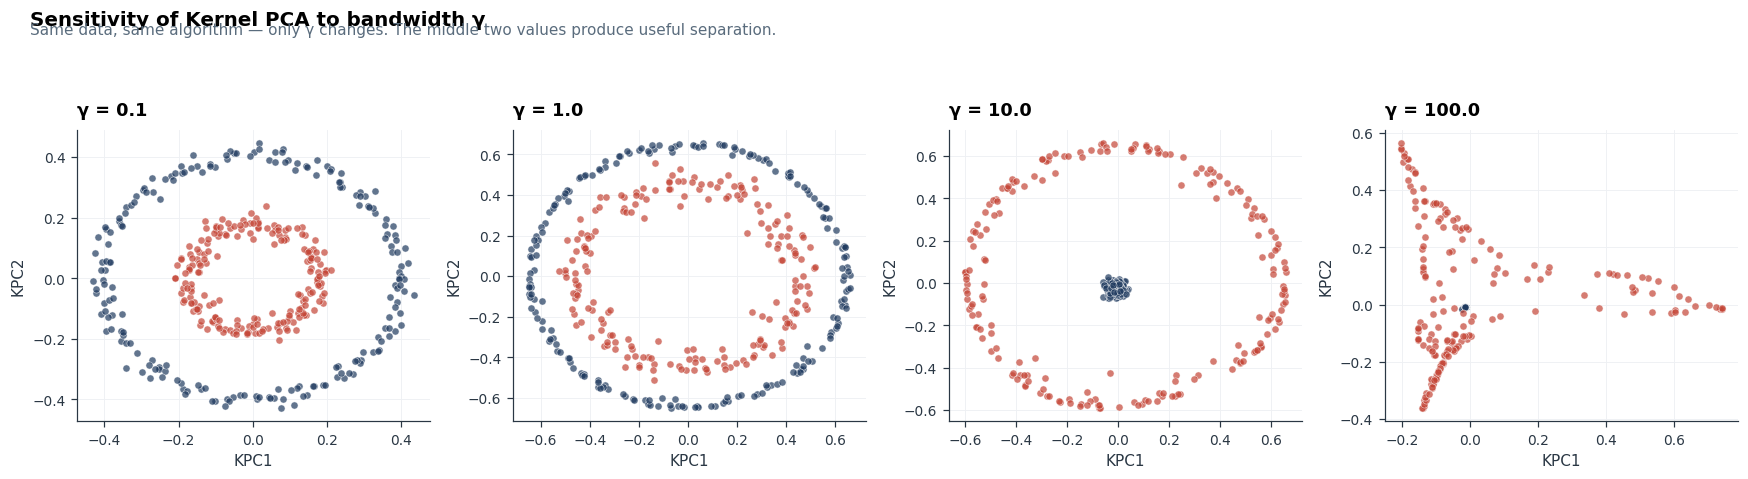

In [ ]:
gammas = [0.1, 1.0, 10.0, 100.0]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.4))
add_figtitle(fig, 'Sensitivity of Kernel PCA to bandwidth γ',
             'Same data, same algorithm — only γ changes. The middle two values produce useful separation.')

for ax, g in zip(axes, gammas):
    Z = KernelPCA(n_components=2, kernel='rbf', gamma=g).fit_transform(X_c)
    ax.scatter(Z[y_c==0, 0], Z[y_c==0, 1], c=PALETTE['navy'], s=22,
               alpha=0.7, edgecolor='white', linewidth=0.4)
    ax.scatter(Z[y_c==1, 0], Z[y_c==1, 1], c=PALETTE['rust'], s=22,
               alpha=0.7, edgecolor='white', linewidth=0.4)
    ax.set_title(f'γ = {g}')
    ax.set_xlabel('KPC1'); ax.set_ylabel('KPC2')

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

---
## 2.5 — Where Kernel PCA struggles: the inverse problem

PCA's killer feature is that we can compress to $k$ numbers and **reconstruct exactly when $k = d$**:
$$\hat{x} = \mu + V_k V_k^\top (x - \mu)$$
This formula is closed-form and exact.

**Kernel PCA does not have this property.** When we map points into kernel feature space via $\phi$, the projection lives in a (possibly infinite-dimensional) abstract space. To reconstruct in input space, we need to find $\hat{x}$ such that $\phi(\hat{x})$ matches the projected feature representation — this is the **pre-image problem**, and in general:

- For RBF kernels, the inverse $\phi^{-1}$ has no closed form
- scikit-learn approximates it using **kernel ridge regression** trained alongside the forward transform
- Even with $k = n$ components, we don't get perfect reconstruction back

This is the price of kernel non-linearity. Let's quantify it.


In [ ]:
# PCA vs KPCA reconstruction error on digits, sweeping k
np.random.seed(0)
n_sub = 500
sub_idx = np.random.choice(len(X_dig), n_sub, replace=False)
X_sub = X_dig[sub_idx]

ks = [5, 10, 20, 30, 50, 64]
errs_pca, errs_kpca = [], []

for k in ks:
    pca_k = PCA(n_components=k).fit(X_sub)
    X_pca_recon = pca_k.inverse_transform(pca_k.transform(X_sub))
    errs_pca.append(np.linalg.norm(X_sub - X_pca_recon) / np.linalg.norm(X_sub))

    kpca_k = KernelPCA(n_components=k, kernel='rbf', gamma=0.001,
                       fit_inverse_transform=True, alpha=0.1, random_state=0)
    Z_k = kpca_k.fit_transform(X_sub)
    X_kpca_recon = kpca_k.inverse_transform(Z_k)
    errs_kpca.append(np.linalg.norm(X_sub - X_kpca_recon) / np.linalg.norm(X_sub))

print("k     PCA error    KPCA error")
print("-" * 32)
for k, ep, ek in zip(ks, errs_pca, errs_kpca):
    print(f"{k:3d}    {ep:.3f}        {ek:.3f}")

k     PCA error    KPCA error
--------------------------------
  5    0.382        0.491
 10    0.286        0.473
 20    0.180        0.465
 30    0.111        0.463
 50    0.013        0.461
 64    0.000        0.461


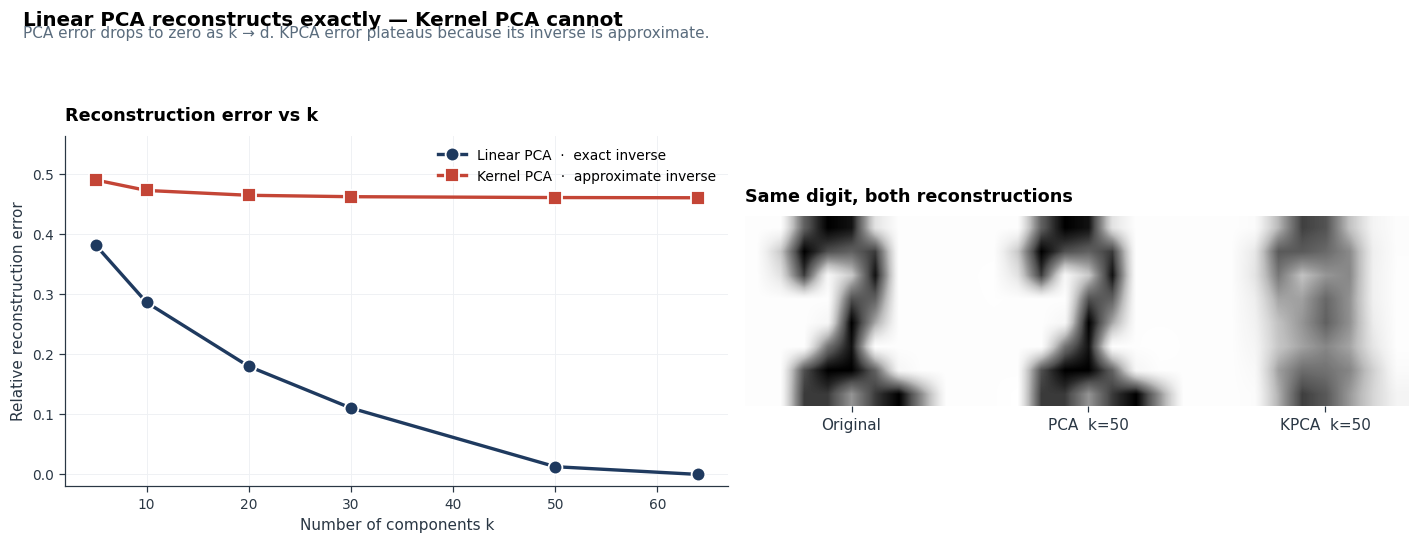

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
add_figtitle(fig, 'Linear PCA reconstructs exactly — Kernel PCA cannot',
             'PCA error drops to zero as k → d. KPCA error plateaus because its inverse is approximate.')

# --- Left: error curves ---
ax = axes[0]
ax.plot(ks, errs_pca, 'o-', color=PALETTE['navy'], lw=2.2, markersize=9,
        markeredgecolor='white', markeredgewidth=1.2, label='Linear PCA  ·  exact inverse')
ax.plot(ks, errs_kpca, 's-', color=PALETTE['rust'], lw=2.2, markersize=9,
        markeredgecolor='white', markeredgewidth=1.2, label='Kernel PCA  ·  approximate inverse')
ax.set_xlabel('Number of components k')
ax.set_ylabel('Relative reconstruction error')
ax.set_title('Reconstruction error vs k')
ax.legend(loc='upper right')
ax.set_ylim(-0.02, max(max(errs_pca), max(errs_kpca)) * 1.15)

# --- Right: side-by-side digit comparison ---
ax = axes[1]
sample_idx = 0
pca_50  = PCA(n_components=50).fit(X_sub)
kpca_50 = KernelPCA(n_components=50, kernel='rbf', gamma=0.001,
                    fit_inverse_transform=True, alpha=0.1, random_state=0).fit(X_sub)

orig    = X_sub[sample_idx].reshape(8, 8)
pca_r   = pca_50.inverse_transform(pca_50.transform(X_sub[sample_idx:sample_idx+1])).reshape(8, 8)
kpca_r  = kpca_50.inverse_transform(kpca_50.transform(X_sub[sample_idx:sample_idx+1])).reshape(8, 8)

# White separator
gap = np.ones((8, 2)) * 0
composite = np.hstack([orig, gap, pca_r, gap, kpca_r])
ax.imshow(composite, cmap='Greys', interpolation='bilinear')
ax.set_xticks([4, 14, 24])
ax.set_xticklabels(['Original', 'PCA  k=50', 'KPCA  k=50'], fontsize=10)
ax.set_yticks([])
ax.set_title('Same digit, both reconstructions')
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

**The key observation.** As $k$ grows, PCA's error drops smoothly to zero. KPCA's error plateaus around 0.46 regardless of $k$, because the bottleneck is not the projection but the *inverse* approximation.

**Practical guidance:**
- **PCA** when we need compression, denoising, or any application requiring invertibility.
- **Kernel PCA** when we only need the *projection* — for example, as a feature transformation feeding a downstream classifier, or for visualization.
- For nonlinear dimensionality reduction *with* reconstruction, use **autoencoders**. They learn encoder and decoder jointly; the decoder is just a neural network — invertible by construction.

KPCA gives us the projection for free; getting the data back costs a separate learning problem with its own approximation error.

---
# Part 3 — Independent Component Analysis (ICA)

## The problem ICA solves
Imagine two microphones in a room, each picking up two voices. ICA recovers the original voices from the mixtures — the "cocktail-party problem."

## How ICA differs from PCA
- **PCA** finds *uncorrelated* directions (orthogonal, max variance — uses second-order statistics)
- **ICA** finds *statistically independent* directions (uses higher-order statistics like kurtosis)

Independence is much stronger than uncorrelatedness.

## Model
Observed data $x = As$, where $s$ are unknown independent sources and $A$ is the unknown mixing matrix. ICA recovers an unmixing matrix $W \approx A^{-1}$ such that $\hat{s} = Wx$.

## Critical assumption: sources are non-Gaussian
If sources were Gaussian, ICA cannot recover them — Gaussians are rotationally symmetric, so any rotation of independent Gaussians is still independent. **At most one source may be Gaussian.**

## FastICA in one line
Maximize the non-Gaussianity of $w^\top x$ over $w$, using kurtosis or negentropy as the proxy.


## Example 3.1 — The cocktail-party problem with real audio

This is where ICA earns its reputation. We'll create synthetic but realistic audio sources (two distinct waveforms — vowel-like and percussive), mix them with a random mixing matrix to simulate two microphone recordings, then ask ICA to unmix them.

We use librosa to play and visualize the audio. If we had real voice clips, we'd just substitute them for the synthetic sources.

In [ ]:
# Generate two synthetic but realistic-sounding sources
sr = 8000        # sample rate
duration = 2.0
t = np.linspace(0, duration, int(sr * duration), endpoint=False)

# Source 1: a voice-like sound (vowel "ah" with formants — sum of harmonics)
fundamental = 220   # Hz, like a male voice
formants = [800, 1200, 2500]   # vowel "ah" formants
voice_like = np.zeros_like(t)
for i, f in enumerate([fundamental, fundamental*2, fundamental*3]):
    voice_like += np.sin(2 * np.pi * f * t) / (i + 1)
# Add formant resonance
for f in formants:
    voice_like += 0.3 * np.sin(2 * np.pi * f * t) * np.exp(-((t - duration/2) / 0.5)**2)
voice_like /= np.abs(voice_like).max()

# Source 2: a percussive/buzzing sound (square wave + noise envelope)
percussive = sg.square(2 * np.pi * 5 * t) * np.exp(-3 * (t % 0.4))
percussive += 0.1 * np.random.randn(len(t))
percussive /= np.abs(percussive).max()

# Stack as sources
S = np.column_stack([voice_like, percussive])

# Mixing matrix (two microphones in different positions)
A = np.array([[0.7, 0.6],
              [0.4, 0.9]])
X_audio = S @ A.T

# Recover with FastICA
ica = FastICA(n_components=2, random_state=42, max_iter=2000)
S_ica = ica.fit_transform(X_audio)

# Recover with PCA (will fail — only decorrelates)
S_pca = PCA(n_components=2).fit_transform(X_audio)

print("Generated 2 sources, mixed them via a 2x2 matrix to simulate microphone recordings.")
print("FastICA fitted in", ica.n_iter_, "iterations.")

Generated 2 sources, mixed them via a 2x2 matrix to simulate microphone recordings.
FastICA fitted in 2 iterations.


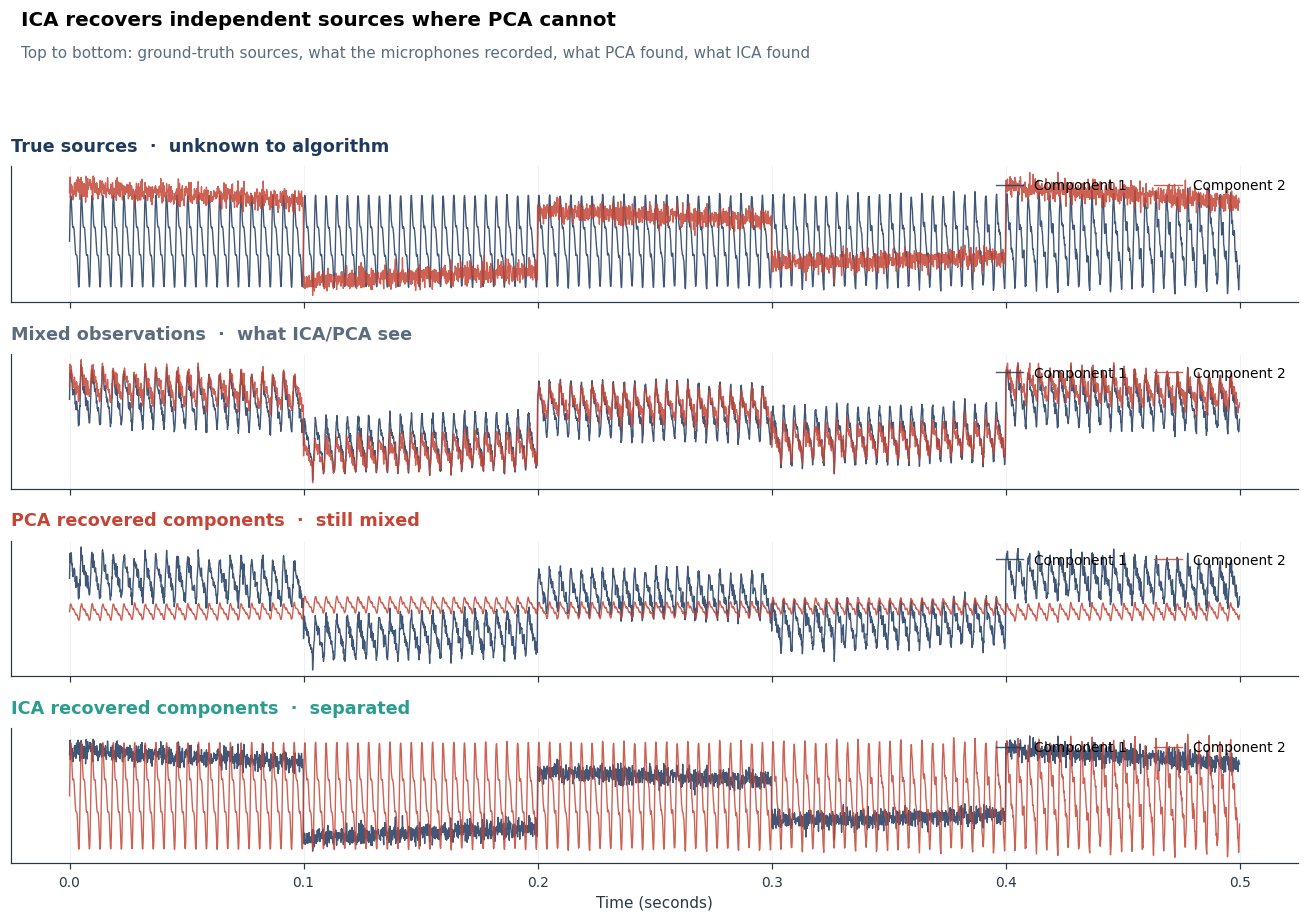

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8.5), sharex=True)
add_figtitle(fig, 'ICA recovers independent sources where PCA cannot',
             'Top to bottom: ground-truth sources, what the microphones recorded, what PCA found, what ICA found')

panel_specs = [
    ('True sources  ·  unknown to algorithm',     S,        PALETTE['navy']),
    ('Mixed observations  ·  what ICA/PCA see',   X_audio,  PALETTE['slate']),
    ('PCA recovered components  ·  still mixed',  S_pca,    PALETTE['rust']),
    ('ICA recovered components  ·  separated',    S_ica,    PALETTE['teal']),
]

for ax, (title, data, accent) in zip(axes, panel_specs):
    n_show = int(0.5 * sr)
    for i, line_color in enumerate([PALETTE['navy'], PALETTE['rust']]):
        ax.plot(t[:n_show], data[:n_show, i], color=line_color, lw=0.9,
                label=f'Component {i+1}', alpha=0.85)
    ax.set_title(title, color=accent)
    ax.set_yticks([])
    ax.legend(loc='upper right', ncol=2)

axes[-1].set_xlabel('Time (seconds)')
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

**Look carefully at panels 3 and 4.** PCA's components are still linear combinations of voice and percussion — both signals are visibly blended in each PCA channel. ICA's components are much closer to the original sources, with each channel dominated by one waveform.

Because we have access to the audio data, we can **listen to the result** and feel the unmixing happen. The cell below plays the four signals.

In [ ]:
# If running interactively, this plays the audio.
# In a headless notebook, this just embeds the audio widget.
try:
    from IPython.display import Audio, display
    print("True source 1 (voice-like):"); display(Audio(S[:, 0], rate=sr))
    print("True source 2 (percussive):"); display(Audio(S[:, 1], rate=sr))
    print("Mixed signal 1 (microphone A):"); display(Audio(X_audio[:, 0], rate=sr))
    print("Mixed signal 2 (microphone B):"); display(Audio(X_audio[:, 1], rate=sr))
    print("ICA recovered 1:"); display(Audio(S_ica[:, 0], rate=sr))
    print("ICA recovered 2:"); display(Audio(S_ica[:, 1], rate=sr))
    print("PCA recovered 1 (still mixed):"); display(Audio(S_pca[:, 0], rate=sr))
    print("PCA recovered 2 (still mixed):"); display(Audio(S_pca[:, 1], rate=sr))
except ImportError:
    print("Audio playback requires IPython. Skipping audio output.")

True source 1 (voice-like):


True source 2 (percussive):


Mixed signal 1 (microphone A):


Mixed signal 2 (microphone B):


ICA recovered 1:


ICA recovered 2:


PCA recovered 1 (still mixed):


PCA recovered 2 (still mixed):


**The audio demo is the part students remember.** When ICA's output sounds like the original sources cleanly separated, the abstract "non-Gaussianity maximization" suddenly has a tangible payoff. PCA's outputs sound like both signals played simultaneously at different volumes — confirming that decorrelation alone doesn't unmix.

**Caveat:** ICA cannot recover the *order* or *scale* of sources. It will give us the right directions, but channels may be permuted or sign-flipped relative to the originals. This is the fundamental ICA ambiguity.

## Example 3.2 — ICA in real research: EEG artifact removal

The single biggest application of ICA in modern neuroscience is **removing eye-blink and muscle artifacts from EEG recordings**. The brain produces neural signals that are roughly statistically independent across cortical regions; eye blinks produce a very different, non-Gaussian signal that contaminates many electrodes simultaneously. ICA can separate them.

We'll simulate this scenario: clean neural sources + a contaminating "blink" artifact, all mixed across multiple "electrode" channels.

In [ ]:
# Simulate an EEG-style scenario
np.random.seed(7)
n_samples_eeg = 3000
t_eeg = np.linspace(0, 12, n_samples_eeg)

# Three "neural" sources — sinusoidal at different frequencies + noise (alpha, beta, theta)
neural_1 = np.sin(2 * np.pi * 10 * t_eeg) + 0.3 * np.random.randn(n_samples_eeg)  # alpha 10Hz
neural_2 = np.sin(2 * np.pi * 20 * t_eeg) + 0.3 * np.random.randn(n_samples_eeg)  # beta 20Hz
neural_3 = np.sin(2 * np.pi * 5 * t_eeg)  + 0.3 * np.random.randn(n_samples_eeg)  # theta 5Hz

# Eye-blink artifact: large, rare, non-Gaussian spikes
blink = np.zeros(n_samples_eeg)
blink_times = [400, 1100, 1800, 2500]
for bt in blink_times:
    blink[bt:bt+80] = 4 * np.exp(-np.linspace(0, 5, 80))

S_eeg = np.column_stack([neural_1, neural_2, neural_3, blink])

# Mix into 4 "electrode" channels via a random mixing matrix
A_eeg = np.random.randn(4, 4)
X_eeg = S_eeg @ A_eeg.T

# Apply ICA to recover the components
ica_eeg = FastICA(n_components=4, random_state=0, max_iter=2000)
S_eeg_recovered = ica_eeg.fit_transform(X_eeg)

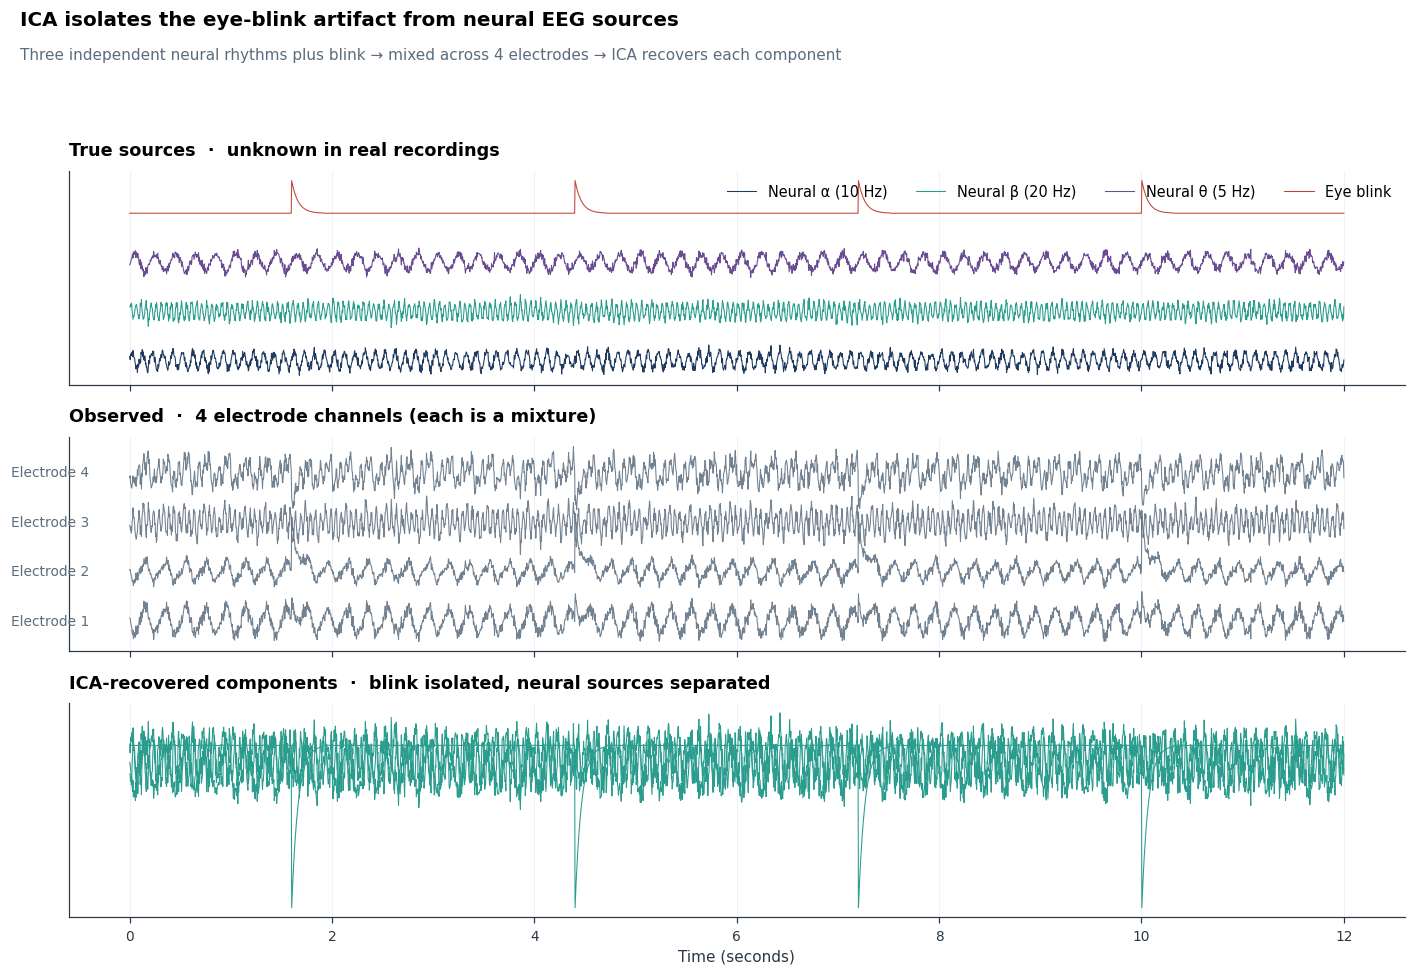

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
add_figtitle(fig, 'ICA isolates the eye-blink artifact from neural EEG sources',
             'Three independent neural rhythms plus blink → mixed across 4 electrodes → ICA recovers each component')

source_colors = [PALETTE['navy'], PALETTE['teal'], PALETTE['plum'], PALETTE['rust']]
labels = ['Neural α (10 Hz)', 'Neural β (20 Hz)', 'Neural θ (5 Hz)', 'Eye blink']

# True sources
ax = axes[0]
offset = 0
for i in range(4):
    ax.plot(t_eeg, S_eeg[:, i] + offset, lw=0.7, color=source_colors[i], label=labels[i])
    offset += 6
ax.set_title('True sources  ·  unknown in real recordings')
ax.legend(loc='upper right', ncol=4, fontsize=9.5); ax.set_yticks([])

# Mixed electrode channels
ax = axes[1]
offset = 0
for i in range(4):
    ax.plot(t_eeg, X_eeg[:, i] + offset, lw=0.7, color=PALETTE['slate'], alpha=0.85)
    ax.text(-0.4, offset, f'Electrode {i+1}', va='center', ha='right',
            fontsize=9, color=PALETTE['slate'])
    offset += 8
ax.set_title('Observed  ·  4 electrode channels (each is a mixture)')
ax.set_yticks([])

# Recovered
ax = axes[2]
offset = 0
for i in range(4):
    ax.plot(t_eeg, S_eeg_recovered[:, i] + offset, lw=0.7, color=PALETTE['teal'])
    offset += 0.4
ax.set_title('ICA-recovered components  ·  blink isolated, neural sources separated')
ax.set_xlabel('Time (seconds)'); ax.set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

**The practical workflow** in real EEG analysis goes:
1. Record raw multi-channel EEG (32, 64, 128, or 256 electrodes).
2. Apply ICA to decompose into independent components.
3. Visually inspect each component. The blink component is obvious — it has a characteristic spike-and-decay shape and a frontal scalp distribution.
4. Set the blink component to zero, then apply the inverse mixing matrix to reconstruct clean EEG without the artifact.

ICA is the workhorse of modern EEG/MEG/fMRI preprocessing. It's used for muscle artifact removal, cardiac artifact removal, identifying default-mode network components, and much more.

---
# Part 4 — Factor Analysis (FA)

## How FA differs from PCA
PCA treats *all* the variance in our data as signal. FA explicitly splits variance into:
- **Common variance** — shared across features, attributable to unobserved factors
- **Unique variance** — specific to each feature (= noise)

This makes FA a true **probabilistic generative model**. PCA is not.

## The model
$$x = \Lambda z + \mu + \epsilon$$

where:
- $z \sim \mathcal{N}(0, I)$ — latent factors ($\dim(z) \ll \dim(x)$)
- $\Lambda$ — factor loadings ($d \times k$)
- $\epsilon \sim \mathcal{N}(0, \Psi)$ where $\Psi$ is **diagonal** (the key constraint)
- $\mu$ — mean

So $\text{Cov}(x) = \Lambda \Lambda^\top + \Psi$. The diagonal $\Psi$ is what separates FA from PCA — it explicitly models per-feature noise.

## When to prefer FA over PCA
- Psychometrics: "intelligence" as a latent factor explaining many test scores
- Finance: a few latent factors explaining many asset returns (Fama–French, Barra)
- Whenever we believe data is generated by a small number of underlying causes plus measurement noise that varies per feature


## Example 4.1 — Synthetic data with known latent factors

We'll generate data from a true 2-factor model with **heteroscedastic** per-feature noise (some features clean, some very noisy), then ask both PCA and FA to recover the factors. FA will distinguish signal from noise; PCA will not.

In [ ]:
np.random.seed(0)
n = 500
k_true = 2
d = 6

# True latent factors and loadings
Z_true = np.random.randn(n, k_true)
Lambda_true = np.random.randn(d, k_true)

# Heteroscedastic noise — feature 0 is clean, feature 5 is very noisy
psi_true = np.array([0.1, 0.2, 0.3, 0.5, 1.5, 3.0])
noise = np.random.randn(n, d) * np.sqrt(psi_true)

X_fa = Z_true @ Lambda_true.T + noise

fa  = FactorAnalysis(n_components=2, random_state=0).fit(X_fa)
pca_fa_demo = PCA(n_components=2).fit(X_fa)

print("True per-feature noise variances Ψ :", psi_true)
print("FA-estimated noise variances Ψ̂   :", np.round(fa.noise_variance_, 2))
print()
print("FA correctly identifies feature 5 as noisiest.")
print("PCA has no concept of per-feature noise — it just rotates.")

True per-feature noise variances Ψ : [0.1 0.2 0.3 0.5 1.5 3. ]
FA-estimated noise variances Ψ̂   : [0.11 0.2  0.28 0.5  1.48 2.81]

FA correctly identifies feature 5 as noisiest.
PCA has no concept of per-feature noise — it just rotates.


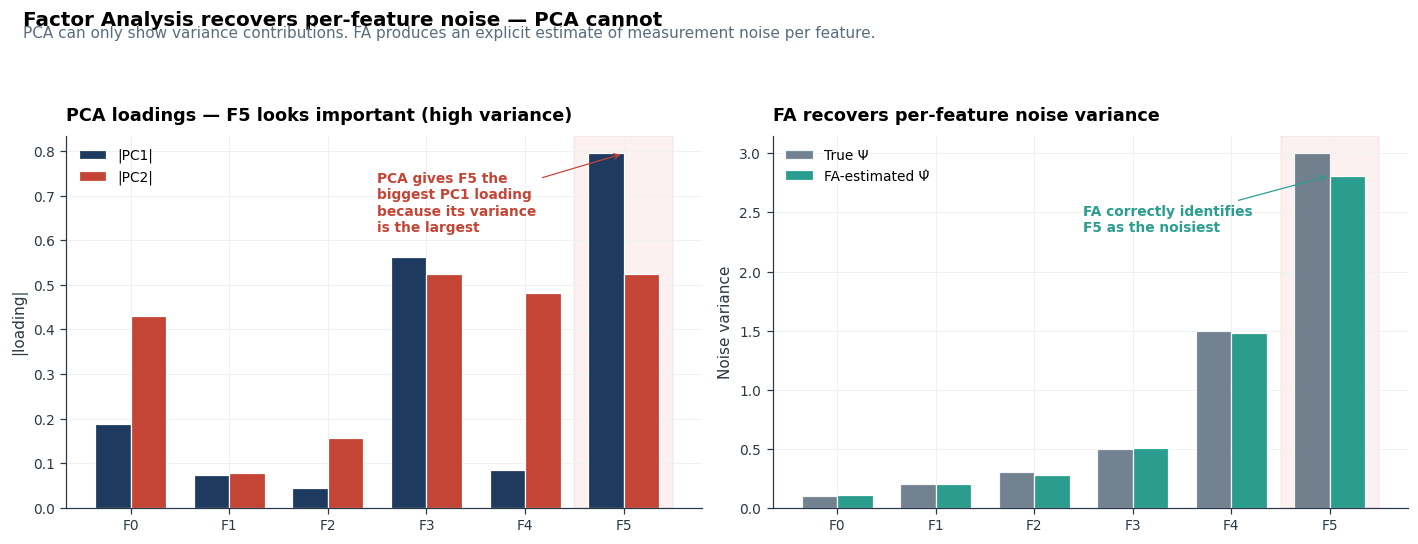

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
add_figtitle(fig, 'Factor Analysis recovers per-feature noise — PCA cannot',
             'PCA can only show variance contributions. FA produces an explicit estimate of measurement noise per feature.')

x = np.arange(d)
width = 0.36

# --- Left: PCA loadings (no noise concept) ---
ax = axes[0]
ax.axvspan(x[5] - 0.5, x[5] + 0.5, color=PALETTE['rust'], alpha=0.07, zorder=0)
ax.bar(x - width/2, np.abs(pca_fa_demo.components_[0]), width,
        label='|PC1|', color=PALETTE['navy'], edgecolor='white', linewidth=0.8)
ax.bar(x + width/2, np.abs(pca_fa_demo.components_[1]), width,
        label='|PC2|', color=PALETTE['rust'], edgecolor='white', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels([f'F{i}' for i in range(d)])
ax.set_title('PCA loadings — F5 looks important (high variance)')
ax.set_ylabel('|loading|'); ax.legend(loc='upper left')
ax.annotate('PCA gives F5 the\nbiggest PC1 loading\nbecause its variance\nis the largest',
            xy=(5, np.abs(pca_fa_demo.components_[0, 5])),
            xytext=(2.5, np.abs(pca_fa_demo.components_[0]).max() * 0.78),
            fontsize=9, color=PALETTE['rust'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=PALETTE['rust'], lw=0.8))

# --- Right: FA's estimated noise variance Ψ̂ vs ground truth ---
ax = axes[1]
ax.axvspan(x[5] - 0.5, x[5] + 0.5, color=PALETTE['rust'], alpha=0.07, zorder=0)
ax.bar(x - width/2, psi_true, width,
        label='True Ψ', color=PALETTE['slate'], edgecolor='white', linewidth=0.8, alpha=0.85)
ax.bar(x + width/2, fa.noise_variance_, width,
        label='FA-estimated Ψ̂', color=PALETTE['teal'], edgecolor='white', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels([f'F{i}' for i in range(d)])
ax.set_title('FA recovers per-feature noise variance')
ax.set_ylabel('Noise variance'); ax.legend(loc='upper left')
ax.annotate('FA correctly identifies\nF5 as the noisiest',
            xy=(5, fa.noise_variance_[5]),
            xytext=(2.5, max(psi_true.max(), fa.noise_variance_.max()) * 0.78),
            fontsize=9, color=PALETTE['teal'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=PALETTE['teal'], lw=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

**The visible difference.** PCA (left) gives F5 the biggest PC1 loading because F5 has the highest variance — and PCA loves variance, regardless of source. But that variance was almost entirely *noise* (we generated F5 with $\Psi_5 = 3.0$).

FA (right) doesn't conflate variance with signal. Its model has an explicit per-feature noise term $\Psi$, and it estimates $\hat{\Psi}$ during fitting. The FA-estimated $\hat{\Psi}$ tracks the true $\Psi$ closely — F5 is correctly flagged as the noisiest feature, and the inferred latent factors are not contaminated by F5's noise.

When features have very different noise levels, FA gives cleaner latent factors than PCA. When we don't know or don't care about per-feature noise, PCA is simpler and faster.

---
# Part 5 — Canonical Correlation Analysis (CCA)

## The problem CCA solves
We have **two views** of the same underlying phenomenon. For example:
- View X: gene expression measurements
- View Y: clinical outcomes

We want linear combinations of X and linear combinations of Y that are **maximally correlated**. Those combinations reveal what the two views share.

## The math
Find vectors $a$ and $b$ that maximize:
$$\rho = \text{corr}(a^\top x, b^\top y) = \frac{a^\top \Sigma_{xy} b}{\sqrt{a^\top \Sigma_{xx} a \cdot b^\top \Sigma_{yy} b}}$$

This reduces to a generalized eigenproblem:
$$\Sigma_{xx}^{-1} \Sigma_{xy} \Sigma_{yy}^{-1} \Sigma_{yx} a = \rho^2 a$$

The largest eigenvalue gives $\rho_1^2$ — the first canonical correlation.

## Where CCA shines
- Multi-view learning: text + image embeddings
- Neuroscience: relating fMRI activity to behavioral measurements
- Genomics: linking gene expression to phenotypes
- Cross-lingual NLP: aligning embeddings across languages


## Example 5.1 — Two views of a shared latent variable

Two 3D views, both driven by a shared 1D latent + view-specific noise. CCA should discover the shared direction.

In [ ]:
np.random.seed(7)
n = 500

z = np.random.randn(n, 1)

W_x = np.array([[1.5], [0.8], [-1.2]])
X_view = z @ W_x.T + 0.5 * np.random.randn(n, 3)

W_y = np.array([[0.9], [-1.6], [1.1]])
Y_view = z @ W_y.T + 0.5 * np.random.randn(n, 3)

cca = CCA(n_components=2)
U, V = cca.fit_transform(X_view, Y_view)

rho1 = np.corrcoef(U[:, 0], V[:, 0])[0, 1]
rho2 = np.corrcoef(U[:, 1], V[:, 1])[0, 1]
print(f"First canonical correlation  ρ₁ = {rho1:.3f}  (should be high — shared latent)")
print(f"Second canonical correlation ρ₂ = {rho2:.3f}  (should be near zero)")

First canonical correlation  ρ₁ = 0.950  (should be high — shared latent)
Second canonical correlation ρ₂ = 0.070  (should be near zero)


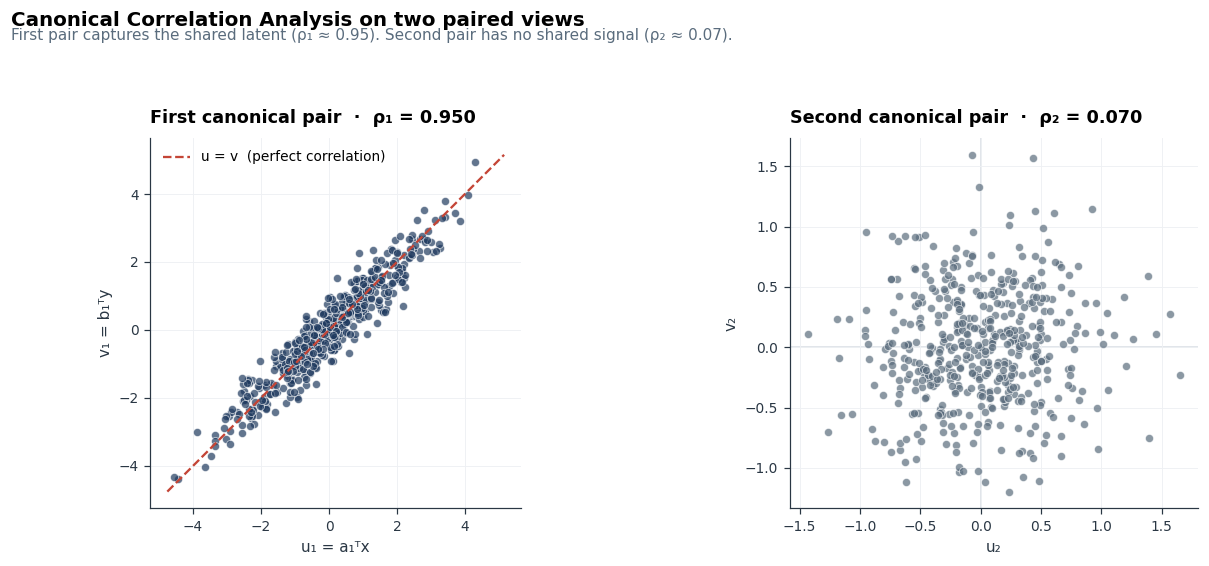

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
add_figtitle(fig, 'Canonical Correlation Analysis on two paired views',
             f'First pair captures the shared latent (ρ₁ ≈ {rho1:.2f}). Second pair has no shared signal (ρ₂ ≈ {rho2:.2f}).')

# --- First canonical pair ---
ax = axes[0]
ax.scatter(U[:, 0], V[:, 0], s=28, alpha=0.7,
           color=PALETTE['navy'], edgecolor='white', linewidth=0.5)
lims = [min(U[:,0].min(), V[:,0].min()) - 0.2, max(U[:,0].max(), V[:,0].max()) + 0.2]
ax.plot(lims, lims, '--', color=PALETTE['rust'], linewidth=1.5,
        label='u = v  (perfect correlation)', zorder=5)
ax.set_xlabel('u₁ = a₁ᵀx'); ax.set_ylabel('v₁ = b₁ᵀy')
ax.set_title(f'First canonical pair  ·  ρ₁ = {rho1:.3f}')
ax.legend(loc='upper left'); ax.set_aspect('equal')

# --- Second canonical pair ---
ax = axes[1]
ax.scatter(U[:, 1], V[:, 1], s=28, alpha=0.7,
           color=PALETTE['slate'], edgecolor='white', linewidth=0.5)
ax.axhline(0, color=PALETTE['fog'], linewidth=1, zorder=0)
ax.axvline(0, color=PALETTE['fog'], linewidth=1, zorder=0)
ax.set_xlabel('u₂'); ax.set_ylabel('v₂')
ax.set_title(f'Second canonical pair  ·  ρ₂ = {rho2:.3f}')
ax.set_aspect('equal')

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

**Reading the plot.** The first canonical pair $(u_1, v_1)$ lies tightly on the line $u = v$ — that's $\rho_1 \approx 1$, showing CCA found the shared latent direction. The second pair is a noisy cloud because there's no second shared dimension.

CCA finds the *common signal* between two datasets while ignoring whatever is private to each view. This is its superpower — and what distinguishes it from PCA, which only sees one dataset at a time.

---
# Summary — when to use what

| Method | Input | Goal | Key assumption | Typical use |
|---|---|---|---|---|
| **PCA** | One dataset $X$ | Decorrelate, reduce dims | Linear correlations dominate | Compression, visualization, denoising |
| **Kernel PCA** | One dataset $X$ | Capture *nonlinear* structure | Kernel matches data geometry | Nonlinear manifolds |
| **ICA** | One dataset $X$ (assumed mixed) | Recover *independent* sources | Sources are non-Gaussian | EEG artifact removal, source separation |
| **Factor Analysis** | One dataset $X$ | Find latent factors + per-feature noise | Linear-Gaussian generative model | Psychometrics, finance |
| **CCA** | Two datasets $X, Y$ | Find shared structure | Shared linear subspace exists | Multi-view learning, genomics |

## Decision flowchart

1. **One dataset or two?** → Two paired views = CCA
2. **Nonlinear structure?** → Yes = Kernel PCA
3. **Mixture of independent sources?** → Yes = ICA
4. **Want a probabilistic generative model?** → Yes = Factor Analysis
5. **Default workhorse** → PCA

## Closing note

We've used `set_aspect('equal')` consistently and printed eigenvalues alongside plots. This is a habit worth keeping: many published figures hide low-variance components by autoscaling axes. Always print the variance ratios alongside any projection plot.

For natural images and large-scale data, PCA gets us a strong baseline but its limitations (Section 1.8) motivate everything in modern representation learning — autoencoders, VAEs, contrastive methods, diffusion models. Each addresses a specific PCA shortcoming.
